## CBOE Volatility Index (VIX)

In [ ]:
import warnings
from pathlib import Path


from datetime import datetime, timedelta, timezone
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


from scipy import stats
from scipy.optimize import minimize

from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.holtwinters import ExponentialSmoothing

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

### Functions for unit root test and heteroskedasticity

In [ ]:
def unit_root_summary(y, name="series"):
    rows = []
    for reg, label in [("c", "constant"), ("ct", "constant + trend")]:
        try:
            adf_res = adfuller(y, regression=reg, autolag="AIC")
            rows.append({
                "series": name,
                "test": f"ADF ({label})",
                "stat": adf_res[0],
                "pvalue": adf_res[1],
                "usedlag": adf_res[2]
            })
        except Exception as e:
            rows.append({
                "series": name,
                "test": f"ADF ({label})",
                "stat": np.nan,
                "pvalue": np.nan,
                "usedlag": np.nan
            })
        try:
            kpss_res = kpss(y, regression=reg, nlags="auto")
            rows.append({
                "series": name,
                "test": f"KPSS ({label})",
                "stat": kpss_res[0],
                "pvalue": kpss_res[1],
                "usedlag": kpss_res[2]
            })
        except Exception:
            rows.append({
                "series": name,
                "test": f"KPSS ({label})",
                "stat": np.nan,
                "pvalue": np.nan,
                "usedlag": np.nan
            })
    return pd.DataFrame(rows)

def arch_lm_table(y, nlags=4):
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(y, nlags=nlags)
    return pd.DataFrame({
        "LM stat": [lm_stat],
        "LM p-value": [lm_pvalue],
        "F stat": [f_stat],
        "F p-value": [f_pvalue],
        "lags": [nlags]
    })

def plot_hist_density_qq(y, title_prefix="Series"):
    yy = np.asarray(y)
    mu, sig = yy.mean(), yy.std(ddof=0)
    x = np.linspace(mu - 4*sig, mu + 4*sig, 400)

    plt.figure(figsize=(10,5))
    plt.hist(yy, bins=30, density=True, alpha=0.5, label="Histogram")
    kde = stats.gaussian_kde(yy)
    plt.plot(x, kde(x), linewidth=2, label="Kernel density")
    plt.plot(x, stats.norm.pdf(x, loc=mu, scale=sig), linewidth=2, label="Normal density")
    plt.title(f"{title_prefix}: histogram, kernel density, and normal density")
    plt.tight_layout()
    plt.legend()
    plt.show()

    plt.figure(figsize=(10,5))
    stats.probplot(yy, dist="norm", plot=plt)
    plt.title(f"{title_prefix}: Normal Q-Q plot")
    plt.tight_layout()
    plt.show()

def get_param(fit, *candidates, default=np.nan):
    names = list(getattr(fit, "param_names", []))
    params = np.asarray(fit.params)
    for c in candidates:
        if c in names:
            return float(params[names.index(c)])
    return default

def fit_arch1(y):
    y = np.asarray(y, dtype=float)
    y = y - np.mean(y)
    n = len(y)
    var0 = np.var(y)
    def unpack(u):
        omega = np.exp(u[0])
        ea = np.exp(u[1])
        alpha = ea / (1 + ea)
        return omega, alpha
    def nll(u):
        omega, alpha = unpack(u)
        h = np.empty(n)
        h[0] = max(var0, omega / max(1e-6, 1-alpha))
        for t in range(1, n):
            h[t] = omega + alpha * y[t-1]**2
        return 0.5 * np.sum(np.log(h) + y**2 / h)
    res = minimize(nll, [np.log(var0*0.1), np.log(0.1/0.9)], method="L-BFGS-B")
    omega, alpha = unpack(res.x)
    h = np.empty(n)
    h[0] = max(var0, omega / max(1e-6, 1-alpha))
    for t in range(1, n):
        h[t] = omega + alpha * y[t-1]**2
    ll = -nll(res.x)
    return {
        "omega": omega, "alpha": alpha, "loglik": ll, "aic": 2*2 - 2*ll,
        "bic": np.log(n)*2 - 2*ll, "h": h, "resid": y/np.sqrt(h), "centered_y": y,
        "success": res.success
    }

def fit_garch11(y):
    y = np.asarray(y, dtype=float)
    y = y - np.mean(y)
    n = len(y)
    var0 = np.var(y)
    def unpack(u):
        omega = np.exp(u[0])
        ea, eb = np.exp(u[1]), np.exp(u[2])
        s = 1 + ea + eb
        alpha = ea / s
        beta = eb / s
        return omega, alpha, beta
    def nll(u):
        omega, alpha, beta = unpack(u)
        h = np.empty(n)
        h[0] = max(var0, omega / max(1e-6, 1-alpha-beta))
        for t in range(1, n):
            h[t] = omega + alpha * y[t-1]**2 + beta * h[t-1]
        return 0.5 * np.sum(np.log(h) + y**2 / h)
    starts = [
        [np.log(var0*0.01), np.log(0.07/0.03), np.log(0.90/0.03)],
        [np.log(var0*0.10), np.log(0.05/0.05), np.log(0.90/0.05)],
        [np.log(var0*0.01), np.log(0.10/0.10), np.log(0.80/0.10)],
    ]
    best = None
    for s in starts:
        r = minimize(nll, s, method="L-BFGS-B")
        if best is None or r.fun < best.fun:
            best = r
    omega, alpha, beta = unpack(best.x)
    h = np.empty(n)
    h[0] = max(var0, omega / max(1e-6, 1-alpha-beta))
    for t in range(1, n):
        h[t] = omega + alpha * y[t-1]**2 + beta * h[t-1]
    ll = -nll(best.x)
    return {
        "omega": omega, "alpha": alpha, "beta": beta, "loglik": ll, "aic": 2*3 - 2*ll,
        "bic": np.log(n)*3 - 2*ll, "h": h, "resid": y/np.sqrt(h), "centered_y": y,
        "success": best.success
    }

def garch_forecast_path(fit_dict, y, steps=10):
    y = np.asarray(y, dtype=float)
    y = y - np.mean(y)
    omega = fit_dict["omega"]
    alpha = fit_dict.get("alpha", 0.0)
    beta = fit_dict.get("beta", 0.0)
    h_last = fit_dict["h"][-1]
    y_last = y[-1]
    out = np.empty(steps)
    out[0] = omega + alpha * y_last**2 + beta * h_last
    for k in range(1, steps):
        out[k] = omega + (alpha + beta) * out[k-1]
    return out

In [ ]:
# Forecast horizon
FORECAST_START = '2026-04-20'
FORECAST_END = '2026-04-24'

TARGET_KEY = 'AVX'
TARGET_LABEL = "VIX"

FORECAST_DATES = pd.date_range(FORECAST_START, FORECAST_END, freq='D')
H = len(FORECAST_DATES)

In [ ]:
def to_2col_array(ci):
    """Return conf_int as a (h,2) numpy array, robust to DataFrame/ndarray."""
    return np.asarray(ci)

def plot_series(y, title, xlabel="t", ylabel="value"):
    plt.figure(figsize=(10,5))
    x_axis = y.index if hasattr(y, "index") else np.arange(1, len(y)+1)
    y_vals = y.values if hasattr(y, "values") else y
    plt.plot(x_axis, y_vals, linewidth=1)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def plot_acf_pacf(y, nlags=24, pacf_method="ywm"):
    yy = np.asarray(y)
    n = len(yy)
    nlags = min(nlags, n//2 - 1)
    nlags = max(nlags, 1)

    r = acf(yy, nlags=nlags, fft=False)
    p = pacf(yy, nlags=nlags, method=pacf_method)

    band = 1.96 / np.sqrt(n)

    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), r, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"Sample ACF (nlags={nlags}), bands = ±1.96/√n (n={n})")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), p, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"Sample PACF (nlags={nlags}), bands = ±1.96/√n (n={n})")
    plt.tight_layout()
    plt.show()

    return r, p

def residual_report(fit, lags=(8,12,16,20)):
    resid = np.asarray(fit.resid)
    lb = acorr_ljungbox(resid, lags=list(lags), return_df=True)
    return resid, lb

def plot_resid_acf(resid, nlags=24, title="Residual ACF"):
    rr = np.asarray(resid)
    n = len(rr)
    nlags = min(nlags, n - 1)

    r = acf(rr, nlags=nlags, fft=False)
    band = 1.96 / np.sqrt(n)

    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), r, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"{title} (bands = ±1.96/√n, n={n})")
    plt.tight_layout()
    plt.show()

def forecast_table_and_plot(fit, steps, y, title_prefix="Forecast"):
    fc = fit.get_forecast(steps=steps)
    mean_fc = np.asarray(fc.predicted_mean)
    ci_arr = to_2col_array(fc.conf_int(alpha=0.05))

    n = len(y)
    idx = np.arange(n+1, n+steps+1)
    fc_df = pd.DataFrame({
        "forecast": mean_fc,
        "lower_95": ci_arr[:,0],
        "upper_95": ci_arr[:,1],
    }, index=idx)

    plt.figure(figsize=(10,5))
    plt.plot(np.arange(1, n+1), np.asarray(y), label="observed", linewidth=1)
    t_fc = np.arange(n+1, n+steps+1)
    plt.plot(t_fc, mean_fc, label="forecast", linewidth=2)
    plt.fill_between(t_fc, ci_arr[:,0], ci_arr[:,1], alpha=0.2, label="95% PI")
    plt.title(f"{title_prefix}")
    plt.xlabel("t")
    plt.tight_layout()
    plt.legend()
    plt.show()

    return fc_df

def ets_benchmarks(y, seasonal_periods=None, seasonal=None):
    yy = pd.Series(y).astype(float)
    ses = ExponentialSmoothing(yy, trend=None, seasonal=None).fit(optimized=True)
    holt = ExponentialSmoothing(yy, trend="add", seasonal=None, damped_trend=False).fit(optimized=True)
    hw = None
    if seasonal_periods is not None and seasonal is not None:
        hw = ExponentialSmoothing(yy, trend="add", seasonal=seasonal,
                                  seasonal_periods=seasonal_periods).fit(optimized=True)
    return ses, holt, hw

def plot_ets_forecasts(y, steps, ses, holt, hw=None, title="ETS benchmarks"):
    yy = np.asarray(y)
    n = len(yy)
    t = np.arange(1, n+1)
    t_fc = np.arange(n+1, n+steps+1)

    f_ses = ses.forecast(steps)
    f_holt = holt.forecast(steps)

    plt.figure(figsize=(10,5))
    plt.plot(t, yy, label="observed", linewidth=1)
    plt.plot(t_fc, f_ses, label="SES", linewidth=2)
    plt.plot(t_fc, f_holt, label="Holt", linewidth=2)
    if hw is not None:
        f_hw = hw.forecast(steps)
        plt.plot(t_fc, f_hw, label="Holt-Winters", linewidth=2)

    plt.title(title)
    plt.xlabel("t")
    plt.tight_layout()
    plt.legend()
    plt.show()

def forecast_df(fit, steps, n_obs):
    fc = fit.get_forecast(steps=steps)
    mean_fc = np.asarray(fc.predicted_mean)
    ci = np.asarray(fc.conf_int(alpha=0.05))
    idx = np.arange(n_obs+1, n_obs+steps+1)
    return pd.DataFrame({
        "forecast": mean_fc,
        "lower_95": ci[:,0],
        "upper_95": ci[:,1]
    }, index=idx)

def forecast_plot(y, fc_df, title="Forecast with 95% PI"):
    y = np.asarray(y)
    n = len(y)
    t = np.arange(1, n+1)
    t_fc = fc_df.index.values
    plt.figure(figsize=(10,5))
    plt.plot(t, y, label="observed", linewidth=1.5)
    plt.plot(t_fc, fc_df["forecast"].values, label="forecast", linewidth=2)
    plt.fill_between(t_fc, fc_df["lower_95"].values, fc_df["upper_95"].values, alpha=0.2, label="95% PI")
    plt.title(title)
    plt.xlabel("t")
    plt.tight_layout()
    plt.legend()
    plt.show()

In [ ]:
def _default_range(days=3*365):
    end = datetime.now(timezone.utc).date()
    start = end - timedelta(days=days)
    return start.isoformat(), end.isoformat()


def _inclusive_end_for_yf(end_str):
    end_dt = datetime.strptime(end_str, "%Y-%m-%d").date()
    inclusive_plus = end_dt + timedelta(days=1)
    return inclusive_plus.isoformat()


def get_vix_df(start: str = None, end: str = None, days: int = 365, symbol: str = "^VIX") -> pd.DataFrame:
    """
    Fetch VIX adjusted close and return a DataFrame aligned to a daily calendar.

    Returns:
      pandas.DataFrame with columns ['date', symbol] where 'date' is dtype datetime64[ns].
    """
    if start is None or end is None:
        default_start, default_end = _default_range(days)
        start = start or default_start
        end = end or default_end

    try:
        _ = datetime.strptime(start, "%Y-%m-%d")
        _ = datetime.strptime(end, "%Y-%m-%d")
    except ValueError:
        raise ValueError("start and end must be in YYYY-MM-DD format")

    yf_end = _inclusive_end_for_yf(end)

    df = yf.download(symbol, start=start, end=yf_end, auto_adjust=True, progress=False)

    date_index = pd.date_range(start=start, end=end, freq="D")

    # If empty, return calendar with NaN floats
    if df is None or df.empty:
        out = pd.DataFrame({"date": date_index, symbol: np.nan})
        out["date"] = pd.to_datetime(out["date"])
        return out

    # If yfinance returned MultiIndex columns (e.g., ('Close', '^VIX')), flatten them
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = ["_".join([str(c) for c in col if c is not None]).strip() for col in df.columns.values]

    # Prefer 'Close' (auto_adjust=True makes it adjusted), fallback to 'Adj Close', else first numeric
    if "Close" in df.columns:
        series = df[["Close"]].rename(columns={"Close": symbol})
    elif "Adj Close" in df.columns:
        series = df[["Adj Close"]].rename(columns={"Adj Close": symbol})
    else:
        numeric_cols = df.select_dtypes(include="number").columns
        if len(numeric_cols) == 0:
            out = pd.DataFrame({"date": date_index, symbol: np.nan})
            out["date"] = pd.to_datetime(out["date"])
            return out
        first_col = numeric_cols[0]
        series = df[[first_col]].rename(columns={first_col: symbol})

    # Align to full calendar
    series.index = pd.to_datetime(series.index).normalize()
    aligned = series.reindex(date_index)
    aligned.index.name = "date"
    aligned = aligned.reset_index()


def get_vix_df(start: str = None, end: str = None, days: int = 365, symbol: str = "^VIX") -> pd.DataFrame:
    """
    Fetch VIX adjusted close and return a DataFrame aligned to a daily calendar.

    Returns:
      pandas.DataFrame with columns ['date', 'value'] where 'date' is dtype datetime64[ns].
    """
    if start is None or end is None:
        default_start, default_end = _default_range(days)
        start = start or default_start
        end = end or default_end

    try:
        _ = datetime.strptime(start, "%Y-%m-%d")
        _ = datetime.strptime(end, "%Y-%m-%d")
    except ValueError:
        raise ValueError("start and end must be in YYYY-MM-DD format")

    yf_end = _inclusive_end_for_yf(end)
    df = yf.download(symbol, start=start, end=yf_end, auto_adjust=True, progress=False)

    date_index = pd.date_range(start=start, end=end, freq="D")

    # If empty, return calendar with NaN floats under 'value'
    if df is None or df.empty:
        out = pd.DataFrame({"date": date_index, "VIX": np.nan})
        out["date"] = pd.to_datetime(out["date"])
        return out

    # Flatten MultiIndex columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = ["_".join([str(c) for c in col if c is not None]).strip() for col in df.columns.values]

    # Pick the appropriate column and rename to a temporary name
    if "Close" in df.columns:
        series = df[["Close"]].rename(columns={"Close": "tmp_value"})
    elif "Adj Close" in df.columns:
        series = df[["Adj Close"]].rename(columns={"Adj Close": "tmp_value"})
    else:
        numeric_cols = df.select_dtypes(include="number").columns
        if len(numeric_cols) == 0:
            out = pd.DataFrame({"date": date_index, "VIX": np.nan})
            out["date"] = pd.to_datetime(out["date"])
            return out
        first_col = numeric_cols[0]
        series = df[[first_col]].rename(columns={first_col: "tmp_value"})

    # Align to full calendar
    series.index = pd.to_datetime(series.index).normalize()
    aligned = series.reindex(date_index)
    aligned.index.name = "date"
    aligned = aligned.reset_index()

    # rename tmp_value to 'value'
    aligned["date"] = pd.to_datetime(aligned["date"])
    aligned = aligned.rename(columns={"tmp_value": "VIX"})
    aligned["VIX"] = aligned["VIX"].astype(float)

    return aligned

In [ ]:
df_live = get_vix_df(days = 365*5)
df_live.head(10)

,date,VIX
0,2021-04-18,NaN
1,2021-04-19,17.2900
2,2021-04-20,18.6800
3,2021-04-21,17.5000
4,2021-04-22,18.7100
5,2021-04-23,17.3300
6,2021-04-24,NaN
7,2021-04-25,NaN
8,2021-04-26,17.6400
9,2021-04-27,17.5600


In [ ]:
def process_live_df(df: pd.DataFrame, date_col: str, target_col: str) -> pd.Series:
    # 1. Clean and convert types
    out = df[[date_col, target_col]].copy()
    out[date_col] = pd.to_datetime(out[date_col], errors='coerce')
    out[target_col] = pd.to_numeric(out[target_col], errors='coerce')

    # 2. Drop invalid rows and sort chronologically
    out = out.dropna(subset=[date_col]).sort_values(date_col)

    # 3. Set date as index and force a Daily frequency
    s = out.set_index(date_col)[target_col].asfreq('D')

    s = s.interpolate(method='time').ffill().bfill()

    return s

In [ ]:
# seperated series from full_series for reproducing results as report is based on results from March 2026
full_series = process_live_df(df_live, 'date', TARGET_LABEL)
series = full_series[:-30]

In [ ]:
n_series = len(series)
print("Number of observations:", n_series)
print("First 10 observations:", series[:10])
print("Last 10 observations:", series[-10:])

Number of observations: 1796
First 10 observations: date
2021-04-18   17.2900
2021-04-19   17.2900
2021-04-20   18.6800
2021-04-21   17.5000
2021-04-22   18.7100
2021-04-23   17.3300
2021-04-24   17.4333
2021-04-25   17.5367
2021-04-26   17.6400
2021-04-27   17.5600
Freq: D, Name: VIX, dtype: float64
Last 10 observations: date
2026-03-09   25.5000
2026-03-10   24.9300
2026-03-11   24.2300
2026-03-12   27.2900
2026-03-13   27.1900
2026-03-14   25.9633
2026-03-15   24.7367
2026-03-16   23.5100
2026-03-17   22.3700
2026-03-18   25.0900
Freq: D, Name: VIX, dtype: float64


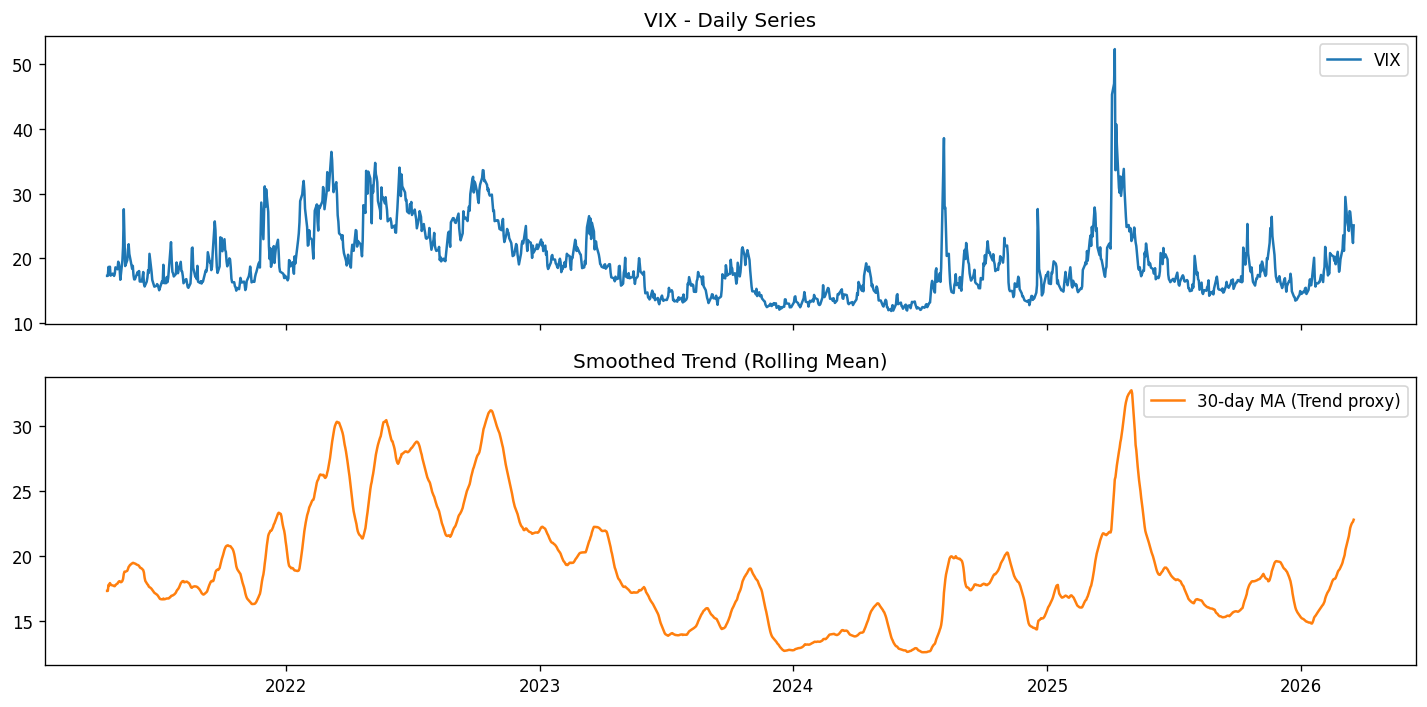

In [ ]:
# -----------------------------
# VISUALIZATION
# -----------------------------

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(series.index, series.values, label=TARGET_LABEL)
axes[0].set_title(f'{TARGET_LABEL} - Daily Series')
axes[0].legend()

roll = series.rolling(30, min_periods=1).mean()
axes[1].plot(series.index, roll.values, color='tab:orange', label='30-day MA (Trend proxy)')
axes[1].set_title('Smoothed Trend (Rolling Mean)')
axes[1].legend()

plt.tight_layout()
plt.show()

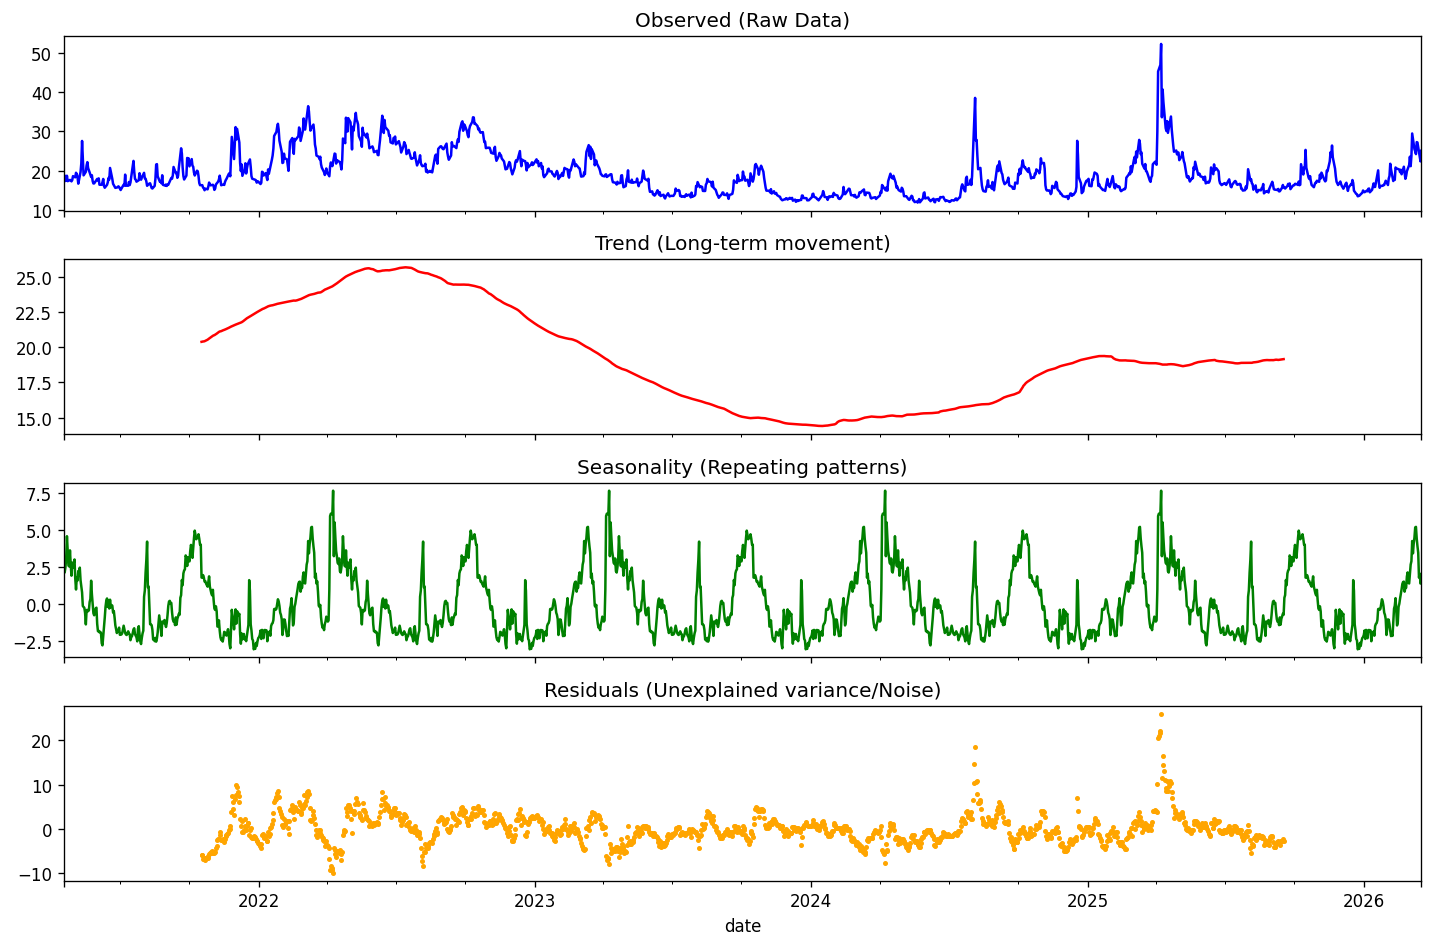

In [ ]:
# -----------------------------
# PLOT TREND/SEASONALITY/RESIDUALS
# -----------------------------

result = seasonal_decompose(series, model='additive', period=int(365))

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

result.observed.plot(ax=ax1, color='blue')
ax1.set_title('Observed (Raw Data)')

# Trend: The long-term progression of the series, stripping away short-term fluctuations.
result.trend.plot(ax=ax2, color='red')
ax2.set_title('Trend (Long-term movement)')

# Seasonal: Repeating patterns that occur over a fixed period (e.g., annual cycles).
result.seasonal.plot(ax=ax3, color='green')
ax3.set_title('Seasonality (Repeating patterns)')

# Residual: What’s left after removing trend and seasonality; the "noise" or "shocks."
result.resid.plot(ax=ax4, color='orange', style='o', markersize=2)
ax4.set_title('Residuals (Unexplained variance/Noise)')

plt.tight_layout()
plt.show()

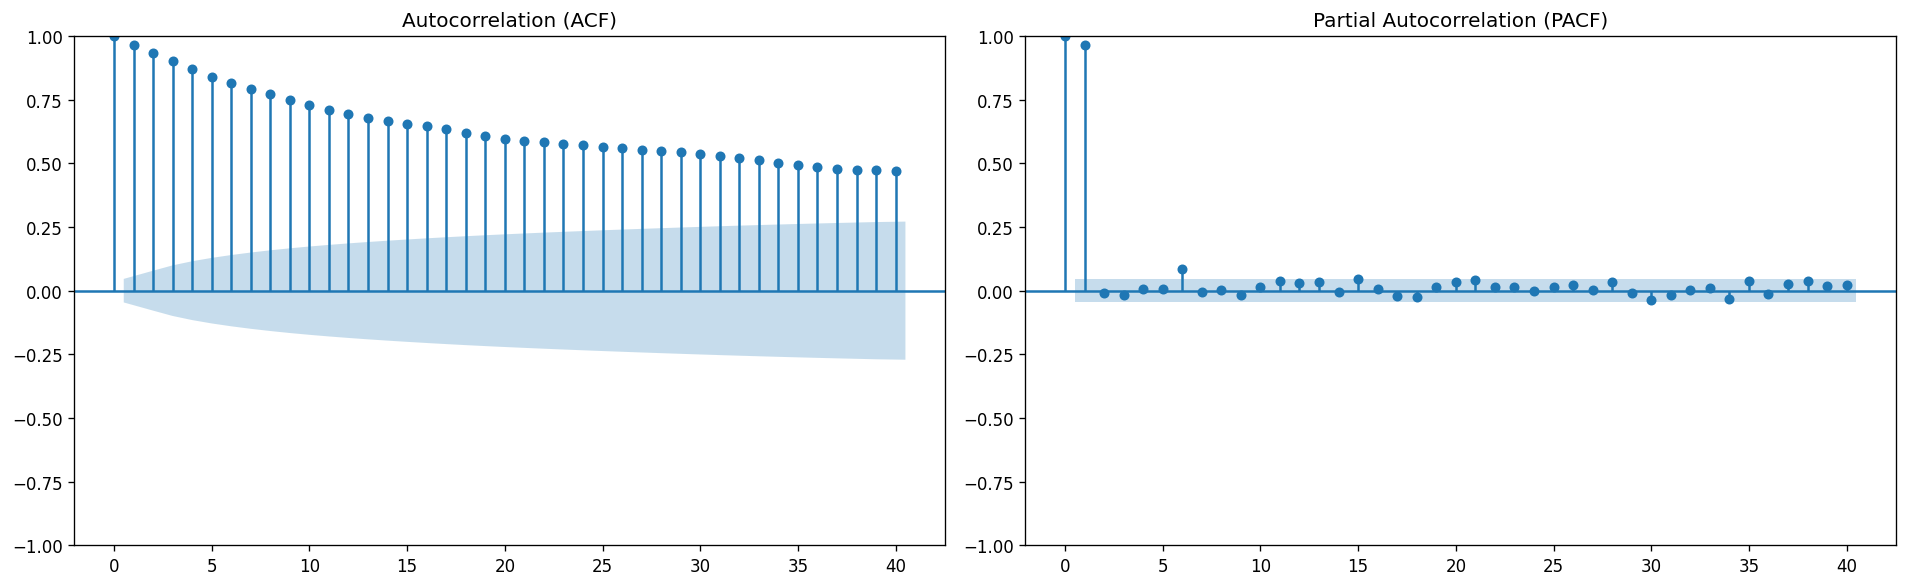

In [ ]:
# -----------------------------
# PLOT ACF AND PACF
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF Plot
plot_acf(series, lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')

# PACF Plot
plot_pacf(series, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF)')

plt.tight_layout()
plt.show()

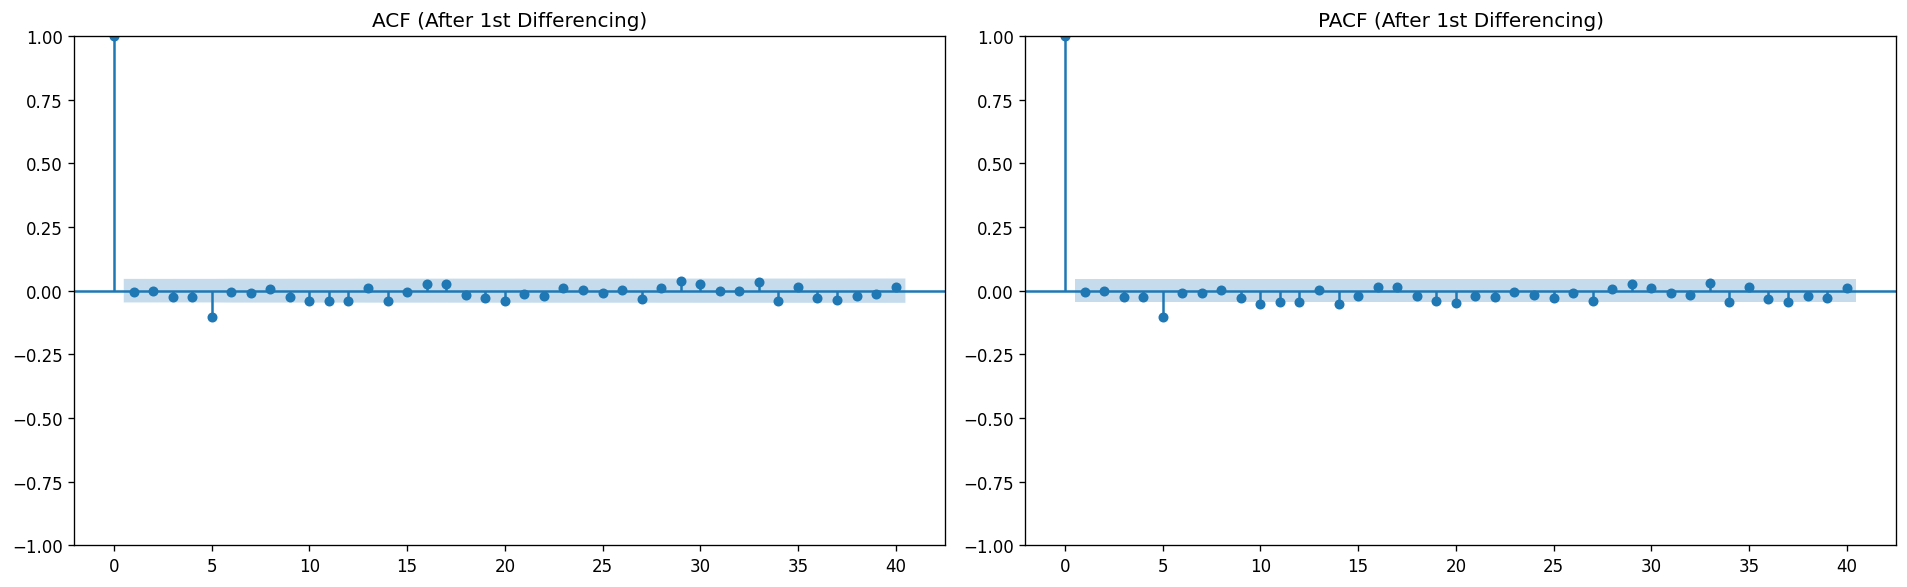

In [ ]:
# -----------------------------
# PLOT ACF AND PACF AFTER FIRST ORDER DIFFERENCING
# -----------------------------

# This calculates the change from one day to the next
series_diff = series.diff().dropna()

# Plotting the results
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF Plot of Differenced Data
plot_acf(series_diff, lags=40, ax=axes[0])
axes[0].set_title('ACF (After 1st Differencing)')

# PACF Plot of Differenced Data
plot_pacf(series_diff, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF (After 1st Differencing)')

plt.tight_layout()
plt.show()

The plots seem to point towards stationary after the first differencing (d=1)

In [ ]:
print("Unit root test summary: Δ VIX")
display(unit_root_summary(series_diff, name="d1_VIX"))

Unit root test summary: Δ VIX


/tmp/ipykernel_22073/296369176.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")
/tmp/ipykernel_22073/296369176.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,d1_VIX,ADF (constant),-14.0212,0.0000,13
1,d1_VIX,KPSS (constant),0.0240,0.1000,22
2,d1_VIX,ADF (constant + trend),-14.0195,0.0000,13
3,d1_VIX,KPSS (constant + trend),0.0216,0.1000,22


Since the PACF of the differenced data showed no significant lags other than at lag 5, Our initial "naive" guess is an ARIMA(0,1,0). This assumes tomorrow's VIX is just today's value plus random noise.

Now we select appropriate p,q from our candidates.

In [ ]:
# --- candidate ARIMA models (p,1,q) ---
candidates = [
    ("ARIMA(0,1,0)", (0,1,0), None),
    ("ARIMA(1,1,1)", (1,1,1), None),
    ("ARIMA(3,1,3)", (3,1,3), None),
    ("ARIMA(2,1,0)", (2,1,0), None),
    ("ARIMA(0,1,2)", (0,1,2), None),
    ("ARIMA(2,1,2)", (2,1,2), None),
    ("ARIMA(5,1,0)", (5,1,0), None),
    ("ARIMA(0,1,5)", (0,1,5), None),
    ("ARIMA(5,1,5)", (5,1,5), None),
]


# --- fit each candidate ---
fits = {}
rows = []
for name, order, seasonality in candidates:
    m = ARIMA(series, order=order, trend="n").fit()
    fits[name] = (m, order)
    rows.append({
        "model": name,
        "order": order,
        "AIC": m.aic,
        "BIC": m.bic
    })

# --- comparison table sorted by AIC ---
cmp = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
cmp

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/st

,model,order,AIC,BIC
0,"ARIMA(5,1,5)","(5, 1, 5)",6151.5541,6211.9745
1,"ARIMA(2,1,2)","(2, 1, 2)",6157.4010,6184.8648
2,"ARIMA(3,1,3)","(3, 1, 3)",6157.4546,6195.9039
3,"ARIMA(0,1,5)","(0, 1, 5)",6169.5251,6202.4817
4,"ARIMA(5,1,0)","(5, 1, 0)",6172.9125,6205.8691
5,"ARIMA(0,1,0)","(0, 1, 0)",6184.3672,6189.8600
6,"ARIMA(0,1,2)","(0, 1, 2)",6188.3420,6204.8203
7,"ARIMA(2,1,0)","(2, 1, 0)",6188.3428,6204.8211
8,"ARIMA(1,1,1)","(1, 1, 1)",6188.3443,6204.8225


Based on the AIC, BIC, we choose ARIMA(2,1,2), as its AIC is not that much different from ARIMA(5,1,5) and looking at BIC, its a simpler model.

### Residual diagnostics for the selected mean model

In [ ]:
best_name = "ARIMA(2,1,2)"
best_fit = fits.get(best_name)[0]

print("\nSelected model by AIC:", best_name)
if best_fit is None:
    raise RuntimeError(f"Best model {best_name} failed to fit.")
print(best_fit.summary())


Selected model by AIC: ARIMA(2,1,2)
                               SARIMAX Results                                
Dep. Variable:                    VIX   No. Observations:                 1796
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -3073.701
Date:                Fri, 17 Apr 2026   AIC                           6157.401
Time:                        02:53:47   BIC                           6184.865
Sample:                    04-18-2021   HQIC                          6167.540
                         - 03-18-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0785      0.290      0.270      0.787      -0.490       0.647
ar.L2          0.8050      0.270      2.979      0.003       0.275       1.335
ma.L1         -

,lb_stat,lb_pvalue
2,2.7528,0.2525
4,2.7596,0.5988
6,12.6408,0.0491
8,13.7298,0.0891


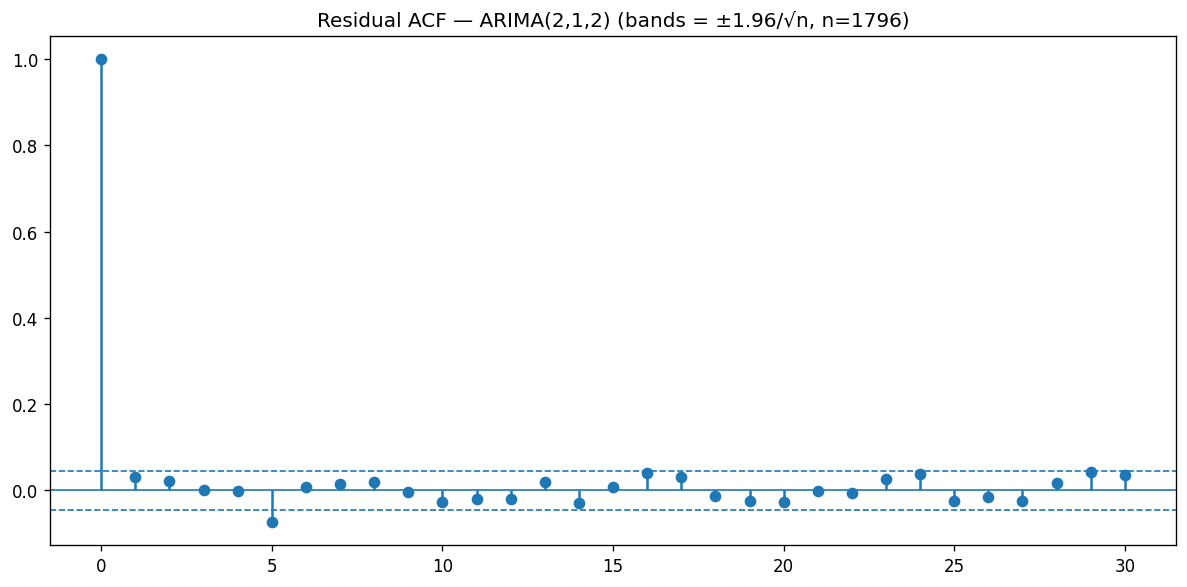

In [ ]:
resid, lb_vix = residual_report(best_fit, lags=(2,4,6,8))
display(lb_vix)
plot_resid_acf(resid, nlags=30, title=f"Residual ACF — {best_name}")

### Forecasting
We perform a simple holdout exercise on the last 6 days.

In [ ]:
h = 6

# --- split ---
train = series[:-h]
test = series[-h:]

model = ARIMA(train, order=(2,1,2), trend="n").fit()

multi_forecast = model.forecast(steps=h)
forecast = np.asarray(multi_forecast)[:h]

fc_tbl = pd.DataFrame({
    "Actual": test.values,
    "Forecast": forecast
}, index=test.index)


from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(test.values, forecast)
print(f"Holdout RMSE: {rmse:.6f}")

display(fc_tbl)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Holdout RMSE: 1.671616


,Actual,Forecast
date,,
2026-03-13,27.1900,26.8368
2026-03-14,25.9633,26.4842
2026-03-15,24.7367,26.0915
2026-03-16,23.5100,25.7762
2026-03-17,22.3700,25.4351
2026-03-18,25.0900,25.1540


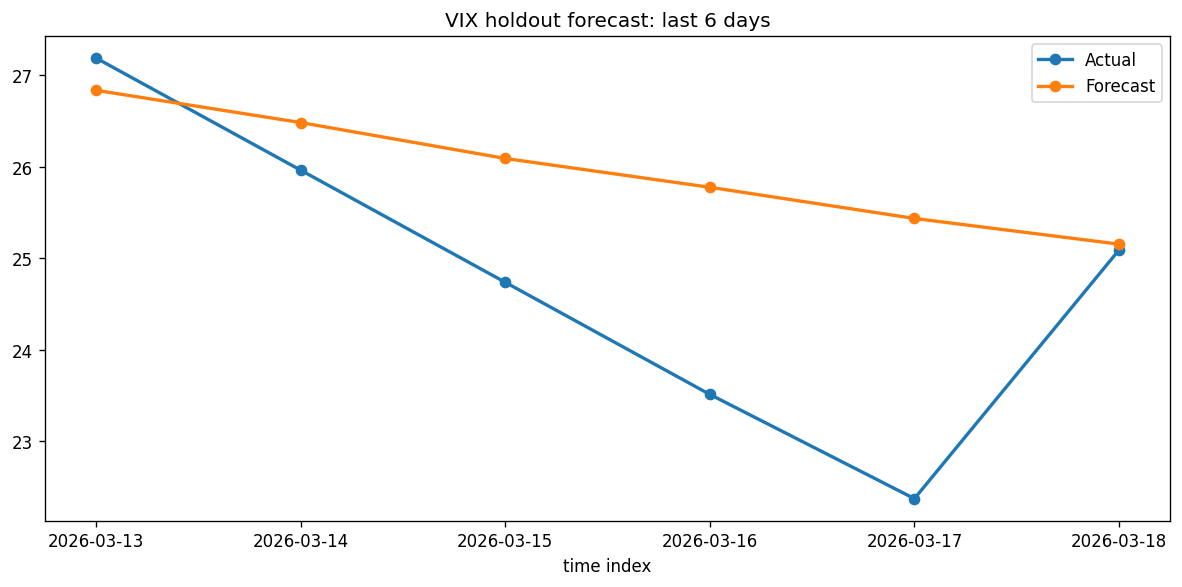

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(fc_tbl.index, fc_tbl["Actual"].values, marker="o", linewidth=2, label="Actual")
plt.plot(fc_tbl.index, fc_tbl["Forecast"].values, marker="o", linewidth=2, label="Forecast")
plt.title("VIX holdout forecast: last 6 days")
plt.xlabel("time index")
plt.tight_layout()
plt.legend()
plt.show()

### Diagnostics: Testing for ARCH

In [ ]:
print("Unit root test summary: exchange rate level")
display(unit_root_summary(series, name="VIX"))

print("Unit root test summary: first difference")
display(unit_root_summary(series_diff))

Unit root test summary: exchange rate level


/tmp/ipykernel_22073/296369176.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")
/tmp/ipykernel_22073/296369176.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,VIX,ADF (constant),-4.7979,0.0001,5
1,VIX,KPSS (constant),1.2371,0.0100,26
2,VIX,ADF (constant + trend),-4.9739,0.0002,5
3,VIX,KPSS (constant + trend),0.4389,0.0100,26


Unit root test summary: first difference


/tmp/ipykernel_22073/296369176.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")
/tmp/ipykernel_22073/296369176.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,series,ADF (constant),-14.0212,0.0000,13
1,series,KPSS (constant),0.0240,0.1000,22
2,series,ADF (constant + trend),-14.0195,0.0000,13
3,series,KPSS (constant + trend),0.0216,0.1000,22


Testing for fat tails

In [ ]:
arima_res = ARIMA(series, order=(2,1,2), trend="n").fit()
resid = arima_res.resid

resid[:5]

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,0
date,
2021-04-18,17.2900
2021-04-19,0.0000
2021-04-20,1.3900
2021-04-21,-1.1242
2021-04-22,1.1925


In [ ]:
from statsmodels.stats.stattools import jarque_bera


jb_stat, jb_pvalue, jb_skew, jb_kurt = jarque_bera(resid)

print("JB stat:", jb_stat)
print("JB p-value:", jb_pvalue)
print("JB skew:", jb_skew)
print("JB kurtosis:", jb_kurt)

JB stat: 124942.43937434157
JB p-value: 0.0
JB skew: 1.7818372278914596
JB kurtosis: 43.705155192182175


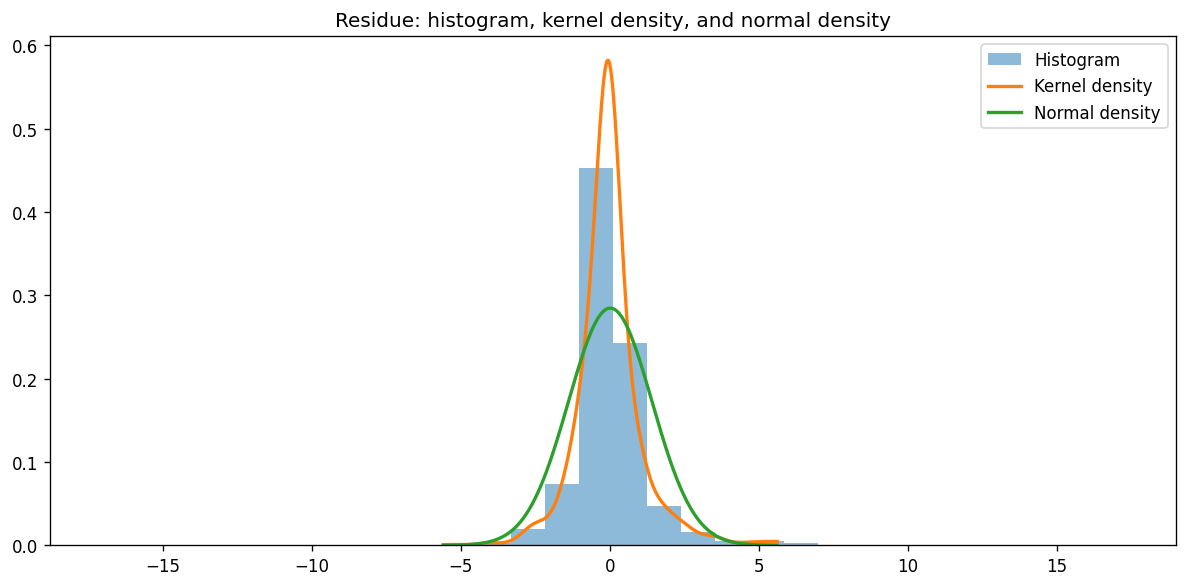

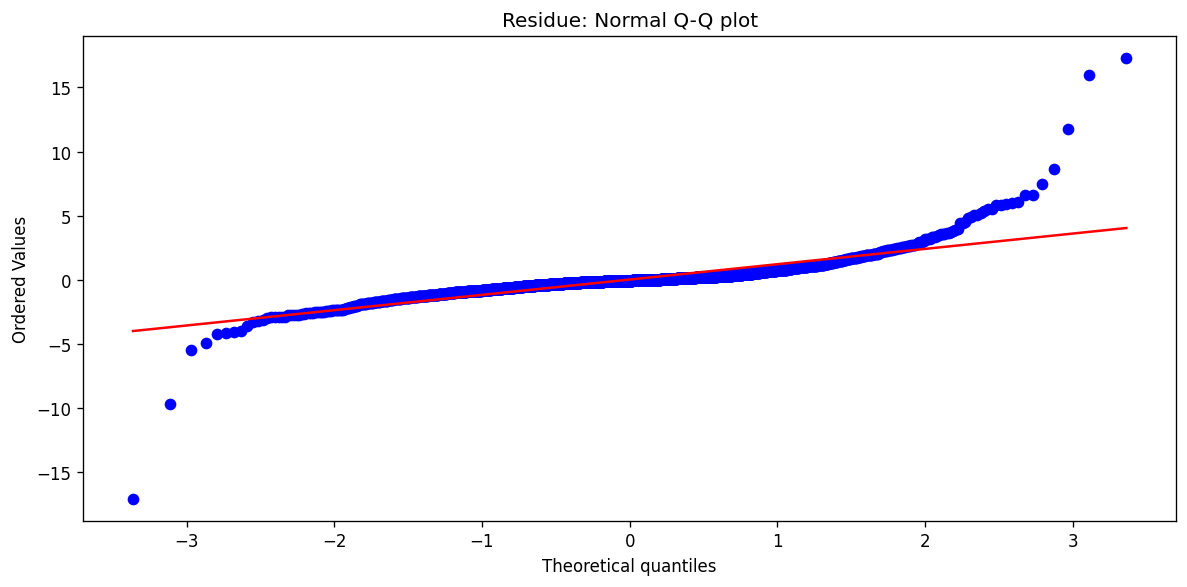

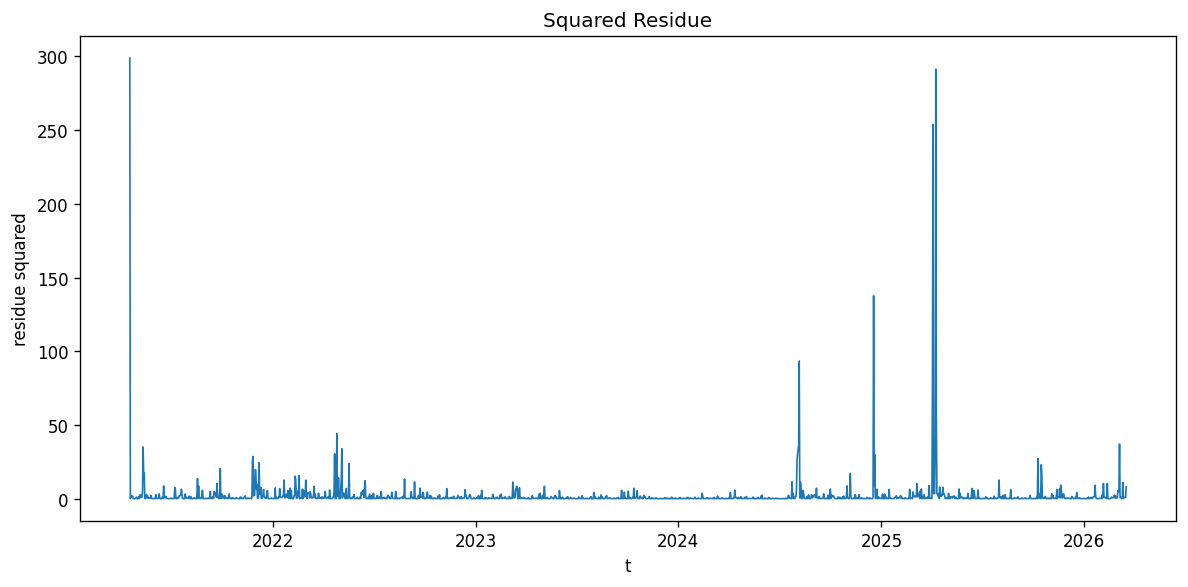

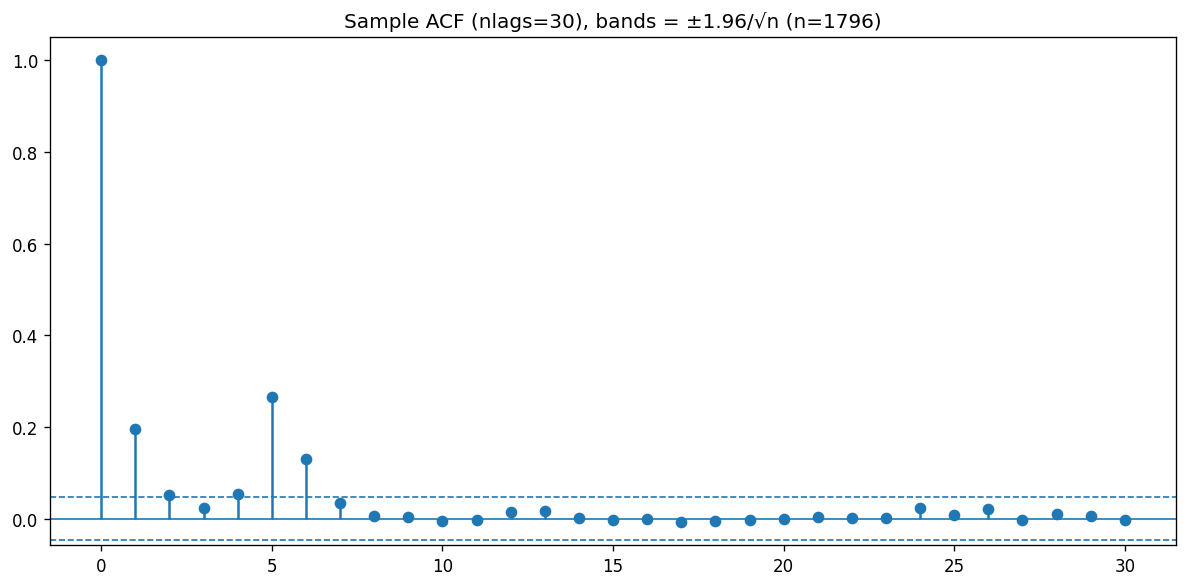

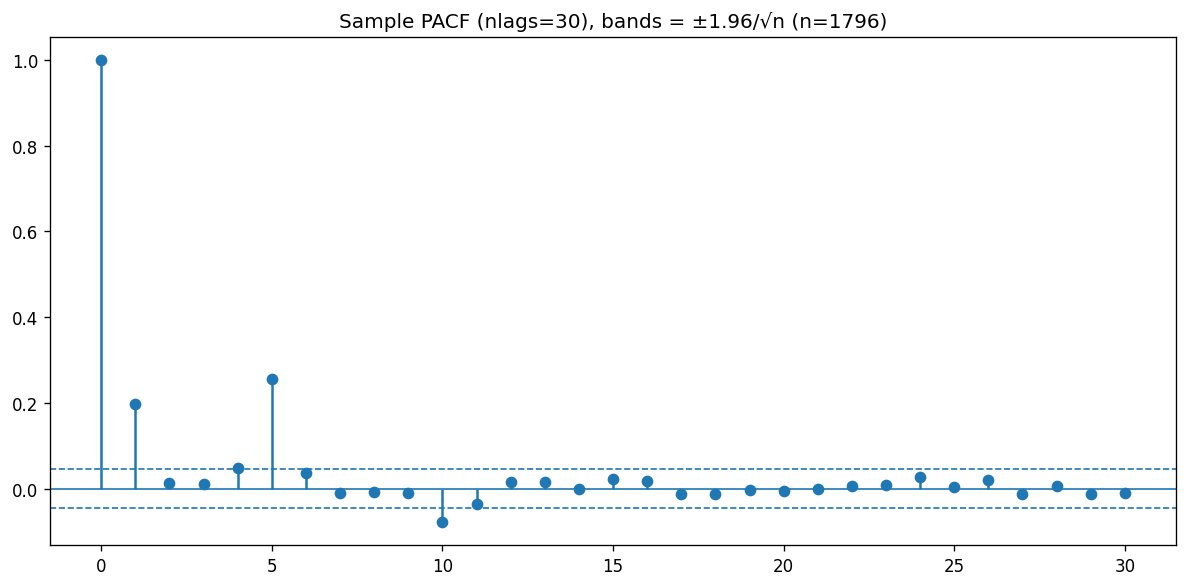

(array([ 1.    ,  0.1961,  0.0512,  0.0224,  0.054 ,  0.2651,  0.1307,
         0.0348,  0.0062,  0.0033, -0.0043, -0.0028,  0.0155,  0.0162,
         0.0011, -0.0024, -0.0012, -0.0079, -0.0046, -0.0027, -0.0019,
         0.0038,  0.0011,  0.0014,  0.0225,  0.0088,  0.0213, -0.0026,
         0.009 ,  0.0058, -0.0022]),
 array([ 1.    ,  0.1961,  0.0132,  0.0103,  0.049 ,  0.2552,  0.0361,
        -0.0112, -0.0071, -0.0117, -0.0787, -0.0355,  0.0154,  0.0154,
        -0.001 ,  0.021 ,  0.0176, -0.0135, -0.0127, -0.0025, -0.0061,
        -0.0017,  0.0054,  0.0092,  0.0278,  0.0029,  0.0202, -0.0135,
         0.0061, -0.0125, -0.0106]))

In [ ]:
plot_hist_density_qq(resid, title_prefix="Residue")
plot_series(resid**2, "Squared Residue", ylabel="residue squared")
plot_acf_pacf(resid**2, nlags=30)

In [ ]:
lm_tbl = arch_lm_table(resid**2, nlags=5)
print("--- ARCH-LM on ARIMA residuals ---")
lm_tbl

--- ARCH-LM on ARIMA residuals ---


,LM stat,LM p-value,F stat,F p-value,lags
0,234.5547,0.0000,53.7995,0.0000,5


Based on p value, the conditional variance depends on the past, so a GARCH-type model is appropriate.

In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.2 MB/s eta 0:00:00


In [ ]:
# Candidate GARCH model fitting and comparison
import numpy as np
import pandas as pd
from arch import arch_model
import scipy.stats as st

candidates = [
    ("GARCH(1,1)", {"mean":"Zero", "vol":"Garch", "p":1, "q":1, "dist":"normal"}),
    ("GARCH(1,1)", {"mean":"Zero", "vol":"Garch", "p":1, "q":1, "dist":"t"}),
    ("GARCH(1,1)", {"mean":"Zero", "vol":"Garch", "p":1, "q":1, "dist":"skewt"}),
    ("ARCH(5)", {"mean":"Zero", "vol":"ARCH", "p":5, "dist":"normal"}),
    ("GARCH(5,1)", {"mean":"Zero", "vol":"Garch", "p":5, "q":1, "dist":"normal"}),
    ("GARCH(1,2)", {"mean":"Zero", "vol":"Garch", "p":1, "q":2, "dist":"normal"}),
    ("GARCH(2,1)", {"mean":"Zero", "vol":"Garch", "p":2, "q":1, "dist":"normal"}),
    ("GJR-GARCH(1,1)", {"mean":"Zero", "vol":"GARCH", "p":1, "o":1, "q":1, "dist":"t"}),
    ("EGARCH(1,1)", {"mean":"Zero", "vol":"EGARCH", "p":1, "q":1, "dist":"t"}),
]

rows = []
fits = {}

for name, args in candidates:
    am = arch_model(resid, **args)
    res = am.fit(disp='off', show_warning=False)
    converged = res.converged if hasattr(res, "converged") else True
    llf = float(res.loglikelihood)
    aic = res.aic
    bic = res.bic
    params = res.params.to_dict()
    fits[name] = res
    rows.append({
        "model": name,
        "dist": args.get("dist"),
        "(p, o, q)": (args.get("p", np.nan), args.get("o", 0), args.get("q", np.nan)),
        "loglik": llf,
        "AIC": aic,
        "BIC": bic
    })

cmp = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
cmp

,model,dist,"(p, o, q)",loglik,AIC,BIC
0,"GJR-GARCH(1,1)",t,"(1, 1, 1)",-2335.6291,4681.2581,4708.7247
1,"GARCH(1,1)",skewt,"(1, 0, 1)",-2340.8599,4691.7198,4719.1864
2,"GARCH(1,1)",t,"(1, 0, 1)",-2355.1032,4718.2065,4740.1797
3,"EGARCH(1,1)",t,"(1, 0, 1)",-2359.6444,4727.2887,4749.2620
4,"GARCH(5,1)",normal,"(5, 0, 1)",-2669.4622,5352.9245,5391.3777
5,ARCH(5),normal,"(5, 0, nan)",-2684.0112,5380.0225,5412.9824
6,"GARCH(1,2)",normal,"(1, 0, 2)",-2697.7485,5403.4971,5425.4703
7,"GARCH(1,1)",normal,"(1, 0, 1)",-2707.7584,5421.5169,5437.9968
8,"GARCH(2,1)",normal,"(2, 0, 1)",-2707.7584,5423.5169,5445.4902


Using GJR-GARCH(1,1) for volatility forecasting.

### Standardized residual diagnostics

In [ ]:
am = arch_model(resid, mean="Zero", vol="GARCH", p=1, o=1, q=1, dist="t")
gjr_garch = am.fit(disp="off")

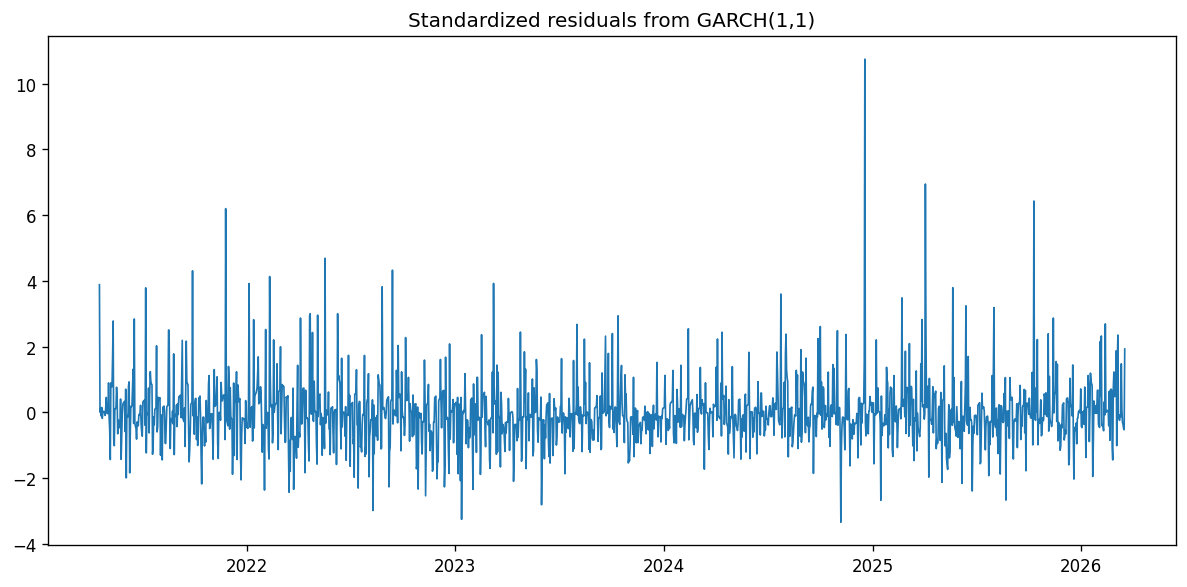

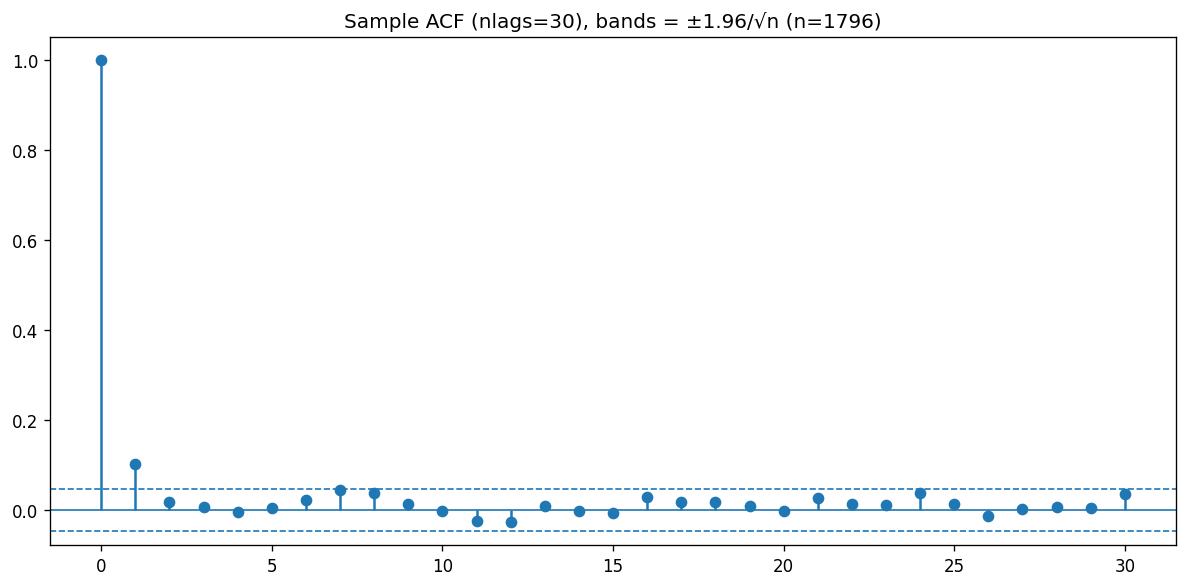

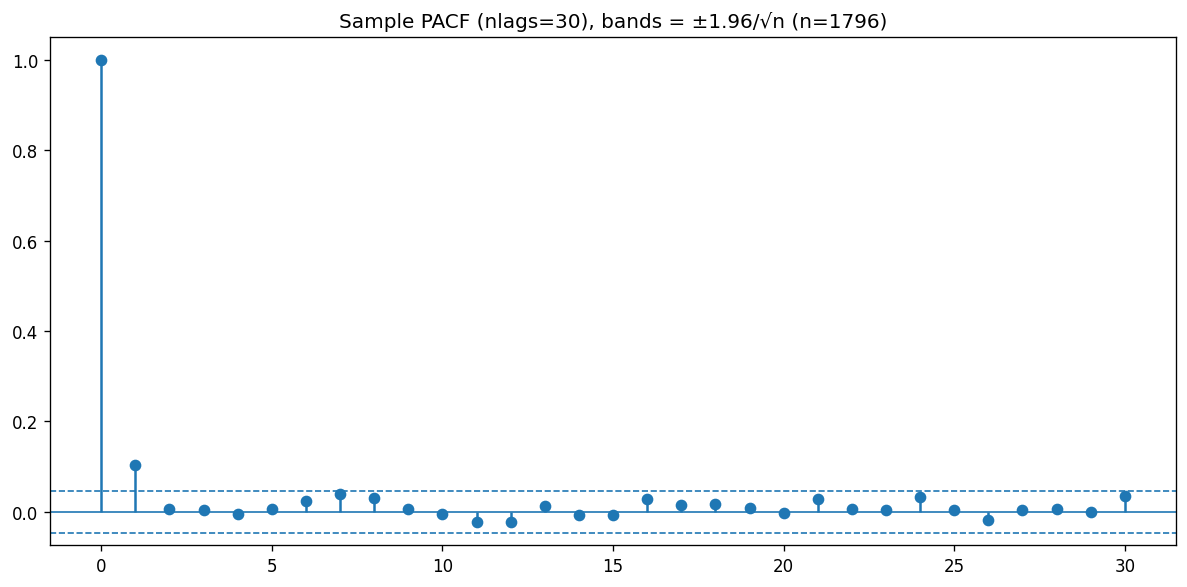

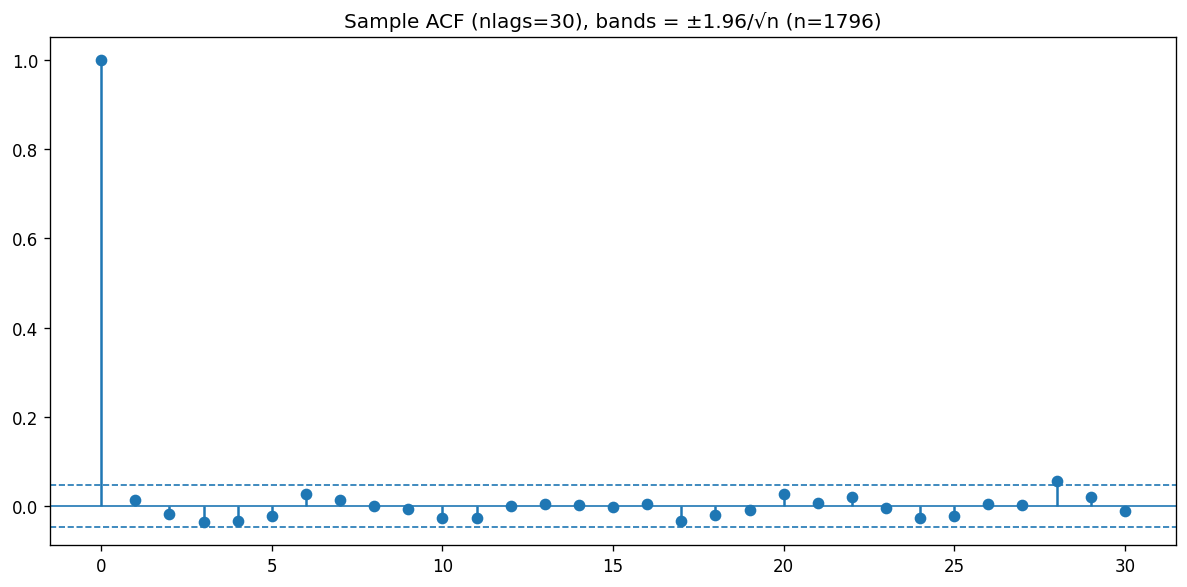

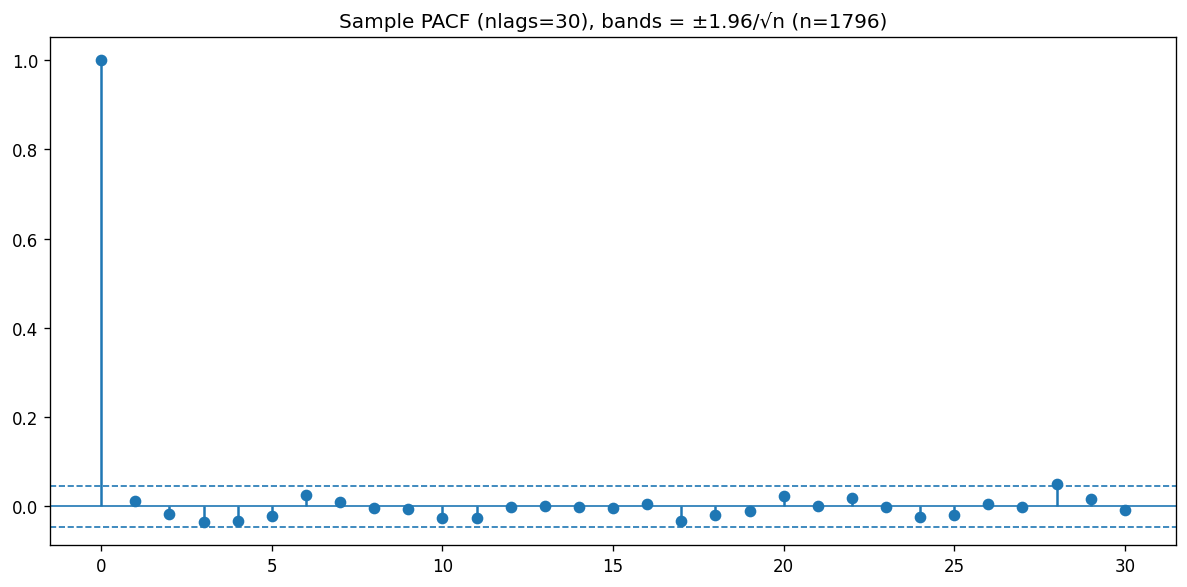

ARCH-LM test on squared standardized residuals


,LM stat,LM p-value,F stat,F p-value,lags
0,5.7986,0.3263,1.1596,0.3268,5


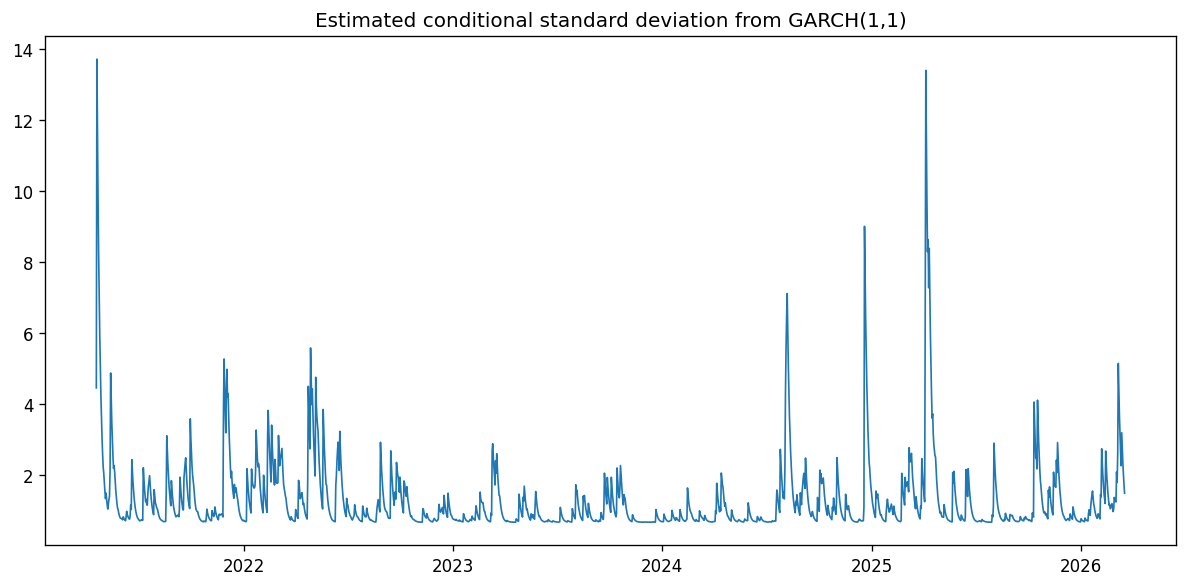

In [ ]:
std_resid = gjr_garch.std_resid
cond_vol = gjr_garch.conditional_volatility.reindex(std_resid.index)

plt.figure(figsize=(10,5))
plt.plot(std_resid, linewidth=1)
plt.title("Standardized residuals from GARCH(1,1)")
plt.tight_layout()
plt.show()

plot_acf_pacf(std_resid, nlags=30)
plot_acf_pacf(std_resid**2, nlags=30)

print("ARCH-LM test on squared standardized residuals")
display(arch_lm_table(std_resid, nlags=5))

plt.figure(figsize=(10,5))
plt.plot(cond_vol.index, cond_vol, linewidth=1)
plt.title("Estimated conditional standard deviation from GARCH(1,1)")
plt.tight_layout()
plt.show()

Based on the ARCH LM test, we can say that it has no remaining ARCH effects

### Final Forecasting

In [ ]:
SPLIT_RATIO = 0.8

series = process_live_df(df_live, 'date', 'VIX') # using complete dataset
split_idx = int(len(series) * SPLIT_RATIO)
train = series.iloc[:split_idx]
test = series.iloc[split_idx:]

print(f"Total Observations: {len(series)}")
print(f"Training set: {len(train)} days (Ends: {train.index[-1].date()})")
print(f"Test set: {len(test)} days (Starts: {test.index[0].date()})")

Total Observations: 1826
Training set: 1460 days (Ends: 2025-04-16)
Test set: 366 days (Starts: 2025-04-17)


In [ ]:
import math
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model
from scipy.stats import t
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tqdm import tqdm

def rolling_arima_gjr_forecast_tqdm(train, test, d=1, arima_order=(2,1,2),
                                    garch_p=1, garch_o=1, garch_q=1,
                                    dist='t', alpha=0.05):
    preds = []
    lowers = []
    uppers = []
    pred_index = []

    train_current = train.copy()
    test_remaining = test.copy()


    total_blocks = math.ceil(len(test) / d) if d > 0 else 0
    pbar = tqdm(total=total_blocks, unit='block')

    try:
        while len(test_remaining) > 0:
            h = min(d, len(test_remaining))

            arima = SARIMAX(train_current, order=arima_order,
                            enforce_stationarity=False, enforce_invertibility=False)
            arima_res = arima.fit(disp=False)

            resid = arima_res.resid.dropna()
            am = arch_model(resid, vol='GARCH', p=garch_p, o=garch_o, q=garch_q,
                            dist=dist, mean='Zero')
            try:
                am_res = am.fit(disp='off', show_warning=False)
            except Exception:
                am = arch_model(resid, vol='GARCH', p=1, o=0, q=1, dist=dist, mean='Zero')
                am_res = am.fit(disp='off', show_warning=False)

            arima_fore = arima_res.get_forecast(steps=h)
            arima_mean = arima_fore.predicted_mean

            garch_fore = am_res.forecast(horizon=h, reindex=False, method='analytic')
            var_fore = garch_fore.variance.values[-1, :]
            try:
                df_t = float(am_res.params.get('nu', 8.0))
            except Exception:
                df_t = 8.0

            q = t.ppf(1 - alpha/2, df=df_t)
            se = np.sqrt(var_fore)
            lower = arima_mean - q * se
            upper = arima_mean + q * se

            idx = test_remaining.index[:h]
            preds.extend(arima_mean.values.tolist())
            lowers.extend(lower.tolist())
            uppers.extend(upper.tolist())
            pred_index.extend(idx.tolist())

            pbar.set_description(f"Fitted window size {len(train_current)}; forecasted {h} steps")
            pbar.update(1)

            to_append = test_remaining.iloc[:h]
            train_current = pd.concat([train_current, to_append])
            test_remaining = test_remaining.iloc[h:]

        pbar.close()

    except Exception:
        pbar.close()
        raise

    preds = pd.Series(preds, index=pred_index).sort_index()
    lowers = pd.Series(lowers, index=pred_index).sort_index()
    uppers = pd.Series(uppers, index=pred_index).sort_index()

    preds = preds.reindex(test.index)
    lowers = lowers.reindex(test.index)
    uppers = uppers.reindex(test.index)

    actual = test.loc[preds.index]
    mask = actual.notna() & preds.notna()
    y_true = actual[mask].values
    y_pred = preds[mask].values

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100

    prev = test.shift(1).loc[preds.index][mask].values

    covered = ((y_true >= lowers[mask].values) & (y_true <= uppers[mask].values)).mean()

    metrics = {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE(%)': mape,
        'PI Coverage (1-alpha)': covered,
        'n_forecasts': len(y_true)
    }

    return preds, lowers, uppers, metrics

In [ ]:
preds, lower, upper, metrics = rolling_arima_gjr_forecast_tqdm(train, test, d=5)

# print metrics
for k, v in metrics.items():
    print(f"{k}: {v}")

# show first 10 rows of results
results = pd.DataFrame({
    'actual': test,
    'forecast': preds,
    'lower95': lower,
    'upper95': upper
})
print("\nFirst 10 forecast rows:")
print(results.head(10))

Fitted window size 1565; forecasted 5 steps:  30%|██▉       | 22/74 [00:16<00:30,  1.70block/s]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Fitted window size 1575; forecasted 5 steps:  32%|███▏      | 24/74 [00:17<00:31,  1.60block/s]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Fitted window size 1585; forecasted 5 steps:  35%|███▌      | 26/74 [00:19<00:30,  1.55block/s]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Fitted window size 1600; forecasted 5 steps:  39%

MAE: 1.4245864953713179
RMSE: 2.092752396030852
MAPE(%): 7.22862168423421
PI Coverage (1-alpha): 0.9344262295081968
n_forecasts: 366

First 10 forecast rows:
            actual  forecast  lower95  upper95
date                                          
2025-04-17 29.6500   32.5577  19.4573  45.6581
2025-04-18 30.6925   32.6345  19.5050  45.7641
2025-04-19 31.7350   32.5789  19.4203  45.7374
2025-04-20 32.7775   32.6237  19.4361  45.8112
2025-04-21 33.8200   32.5892  19.3727  45.8057
2025-04-22 30.5700   33.8889  25.8831  41.8947
2025-04-23 28.4500   33.8471  25.7916  41.9026
2025-04-24 26.4700   33.8851  25.7803  41.9900
2025-04-25 24.8400   33.8558  25.7018  42.0097
2025-04-26 24.9433   33.8799  25.6771  42.0827


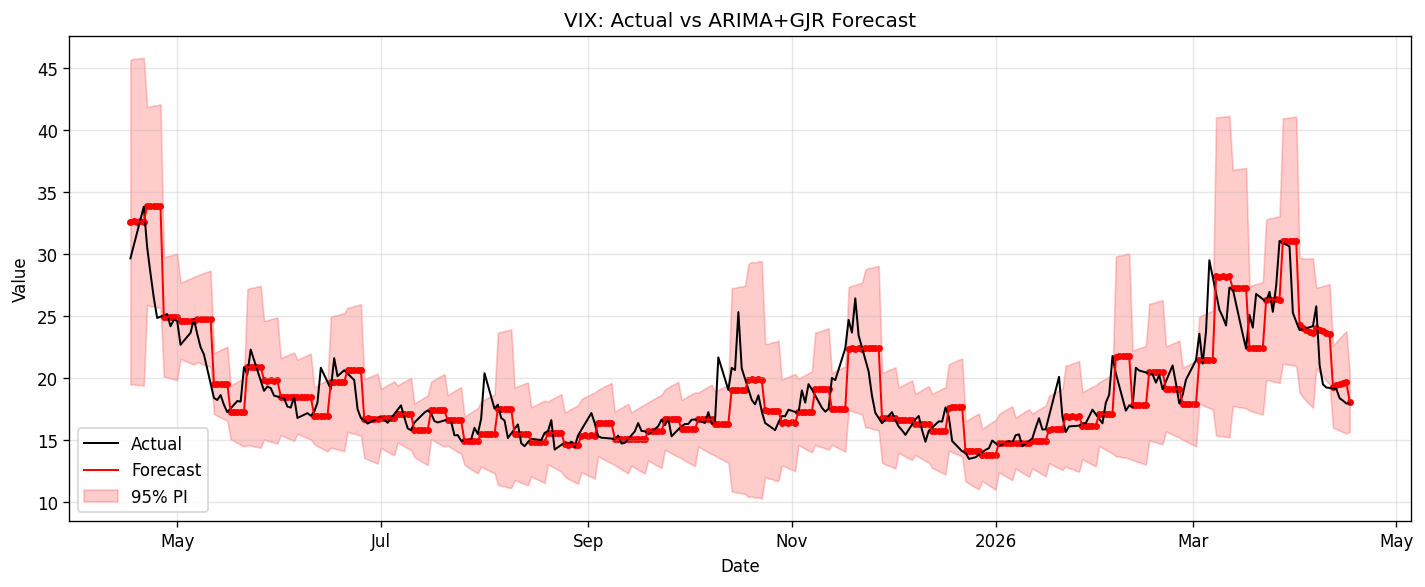

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_forecasts(actual, forecast, lower, upper, title="Actual vs Forecast",
                   figsize=(12,5), xlabel="Date", ylabel="Value"):

    df = pd.DataFrame({
        'actual': actual,
        'forecast': forecast,
        'lower': lower,
        'upper': upper
    }).sort_index().dropna(subset=['forecast'])

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(df.index, df['actual'], color='black', label='Actual', linewidth=1.2)
    ax.plot(df.index, df['forecast'], color='red', label='Forecast', linewidth=1.2)
    ax.fill_between(df.index, df['lower'], df['upper'], color='red', alpha=0.2, label='95% PI')

    ax.scatter(df.index, df['forecast'], color='red', s=10)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)

    if hasattr(df.index, 'to_pydatetime'):
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))

    plt.tight_layout()
    plt.show()

plot_forecasts(test, preds, lower, upper, title="VIX: Actual vs ARIMA+GJR Forecast")

In [ ]:
# Forecast horizon
FORECAST_START = '2026-04-20'
FORECAST_END = '2026-04-24'

# Parse forecast dates
forecast_start = pd.to_datetime(FORECAST_START)
forecast_end = pd.to_datetime(FORECAST_END)
forecast_dates = pd.date_range(start=forecast_start, end=forecast_end, freq='D')
h_forecast = len(forecast_dates)

# Refit models on the full series for final forecast
arima_final = SARIMAX(series, order=(2,1,2), enforce_stationarity=False, enforce_invertibility=False)
arima_res_final = arima_final.fit(disp=False)

# Fit GJR-GARCH(1,1,1) on full residuals
resid_final = arima_res_final.resid.dropna()
am_final = arch_model(resid_final, vol='GARCH', p=1, o=1, q=1, dist='t', mean='Zero')
try:
    am_res_final = am_final.fit(disp='off', show_warning=False)
except Exception:
    am_final = arch_model(resid_final, vol='GARCH', p=1, o=0, q=1, dist='t', mean='Zero')
    am_res_final = am_final.fit(disp='off', show_warning=False)

# Generate forecasts for target horizon
arima_fore_final = arima_res_final.get_forecast(steps=h_forecast)
arima_mean_final = arima_fore_final.predicted_mean

# GARCH variance forecast
garch_fore_final = am_res_final.forecast(horizon=h_forecast, reindex=False, method='analytic')
var_fore_final = garch_fore_final.variance.values[-1, :]


try:
    df_t_final = float(am_res_final.params.get('nu', 8.0))
except Exception:
    df_t_final = 8.0

# Calculate 95% prediction intervals
alpha = 0.05
q = t.ppf(1 - alpha/2, df=df_t_final)
se_final = np.sqrt(var_fore_final)
lower_final = arima_mean_final - q * se_final
upper_final = arima_mean_final + q * se_final

# Assemble forecast results
forecast_results = pd.DataFrame({
    'date': forecast_dates,
    'forecast': arima_mean_final.values,
    'lower95': lower_final.values,
    'upper95': upper_final.values
})
forecast_results = forecast_results.set_index('date')

print("="*60)
print(f"VIX Forecast for {FORECAST_START} to {FORECAST_END}")
print("="*60)
pd.options.display.float_format = '{:.4f}'.format
print(forecast_results)
print("="*60)

VIX Forecast for 2026-04-20 to 2026-04-24
            forecast  lower95  upper95
date                                  
2026-04-20   18.0915  15.6947  20.4883
2026-04-21   18.2362  15.5261  20.9463
2026-04-22   18.3706  15.3798  21.3614
2026-04-23   18.4959  15.2486  21.7432
2026-04-24   18.6126  15.1276  22.0976


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Bitcoin-USD Prices

### Configuration & Dataloader

In [ ]:
BTC_TICKER     = "BTC-USD"
DATA_START     = "2020-01-01"
DATA_END       = "2026-04-19"          # Modify on April 19
FORECAST_DATES = pd.date_range("2026-04-20", periods=5, freq="D")
H              = len(FORECAST_DATES)   # 5 steps

ARIMA_CANDIDATES = [
    (1,1,0), (0,1,1), (1,1,1),
    (2,1,0), (0,1,2), (2,1,2),
    (3,1,0), (0,1,3), (3,1,3),
]


import yfinance as yf

_raw = yf.download(BTC_TICKER, start=DATA_START, end=DATA_END,
                   auto_adjust=True, progress=False)
btc_close = _raw["Close"].squeeze().dropna()
btc_close.index = pd.to_datetime(btc_close.index).tz_localize(None)
btc_close.name  = "BTC-USD"

log_price      = np.log(btc_close)
log_price.name = "log(BTC-USD)"

print(f"Data    : {btc_close.index[0].date()} → {btc_close.index[-1].date()}  ({len(btc_close)} obs)")
print(f"Forecast: {FORECAST_DATES[0].date()} → {FORECAST_DATES[-1].date()}  (H={H})")
print()
display(btc_close.describe().to_frame().T.round(2))

Data    : 2020-01-01 → 2026-04-17  (2299 obs)
Forecast: 2026-04-20 → 2026-04-24  (H=5)



,count,mean,std,min,25%,50%,75%,max
BTC-USD,2299.0,48521.43,31336.37,4970.79,22947.53,41929.76,67581.67,124752.53


### EDA

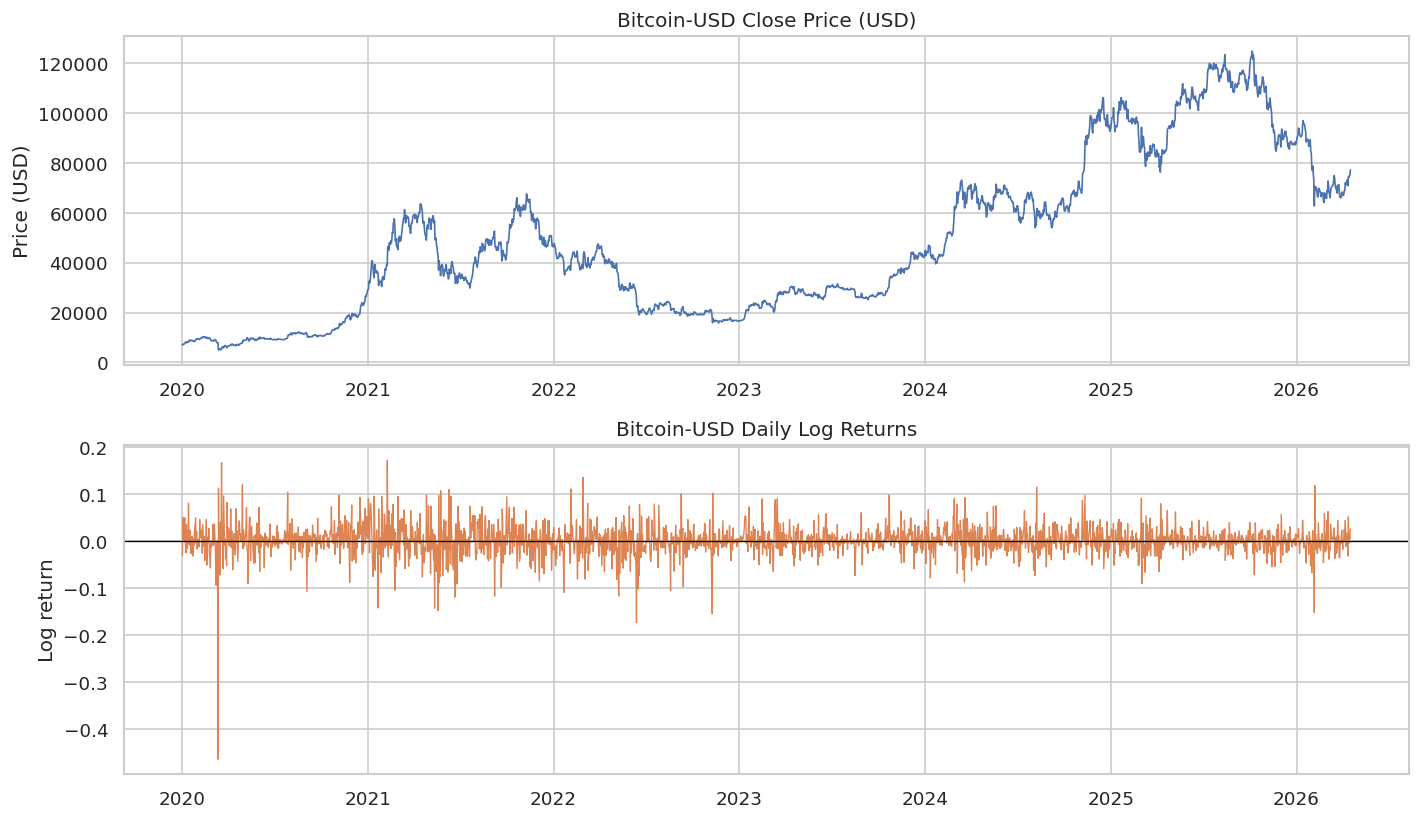

In [ ]:
log_ret      = log_price.diff().dropna()
log_ret.name = "BTC log return"

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(btc_close.index, btc_close.values, linewidth=1)
axes[0].set_title("Bitcoin-USD Close Price (USD)")
axes[0].set_ylabel("Price (USD)")

axes[1].plot(log_ret.index, log_ret.values, linewidth=0.8, color="C1")
axes[1].axhline(0, linewidth=0.8, color="black")
axes[1].set_title("Bitcoin-USD Daily Log Returns")
axes[1].set_ylabel("Log return")
plt.tight_layout()
plt.show()

### Stationary & ACF/PACF

── Unit-root tests : log price ────────────────────────────────


,series,test,stat,pvalue,usedlag
0,log(BTC-USD),ADF (constant),-1.811617,0.374710,9
1,log(BTC-USD),KPSS (constant),4.815292,0.010000,29
2,log(BTC-USD),ADF (constant + trend),-1.770925,0.718606,9
3,log(BTC-USD),KPSS (constant + trend),0.508272,0.010000,29



── Unit-root tests : log return (first difference) ───────────


,series,test,stat,pvalue,usedlag
0,BTC log return,ADF (constant),-15.703343,1.387492e-28,8
1,BTC log return,KPSS (constant),0.187575,1.000000e-01,8
2,BTC log return,ADF (constant + trend),-15.729369,1.226797e-22,8
3,BTC log return,KPSS (constant + trend),0.108104,1.000000e-01,8



── ACF / PACF of log return ───────────────────────────────────


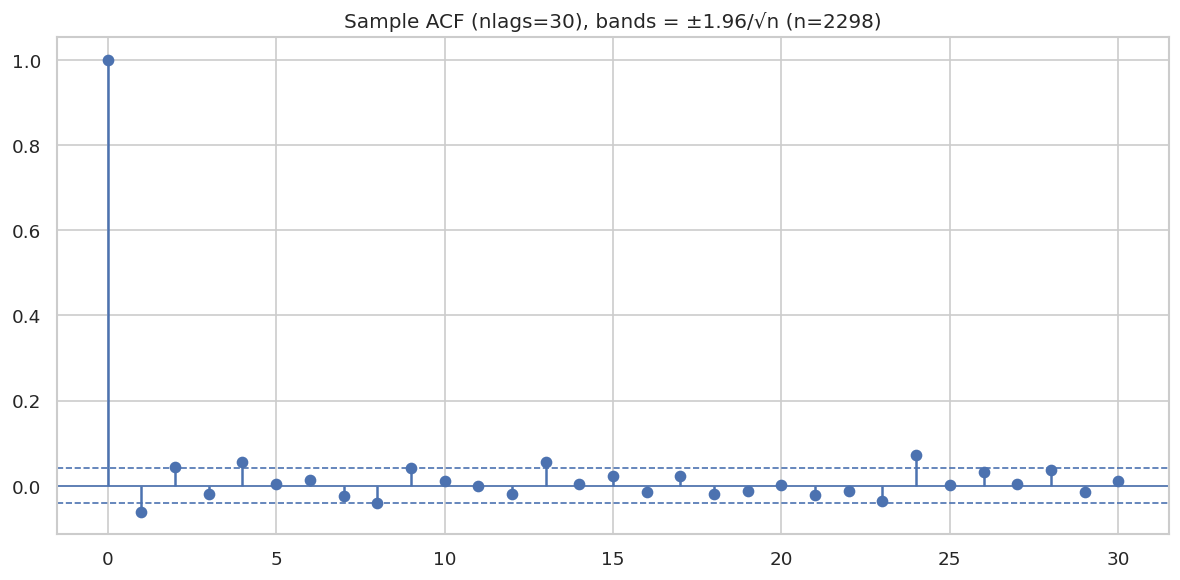

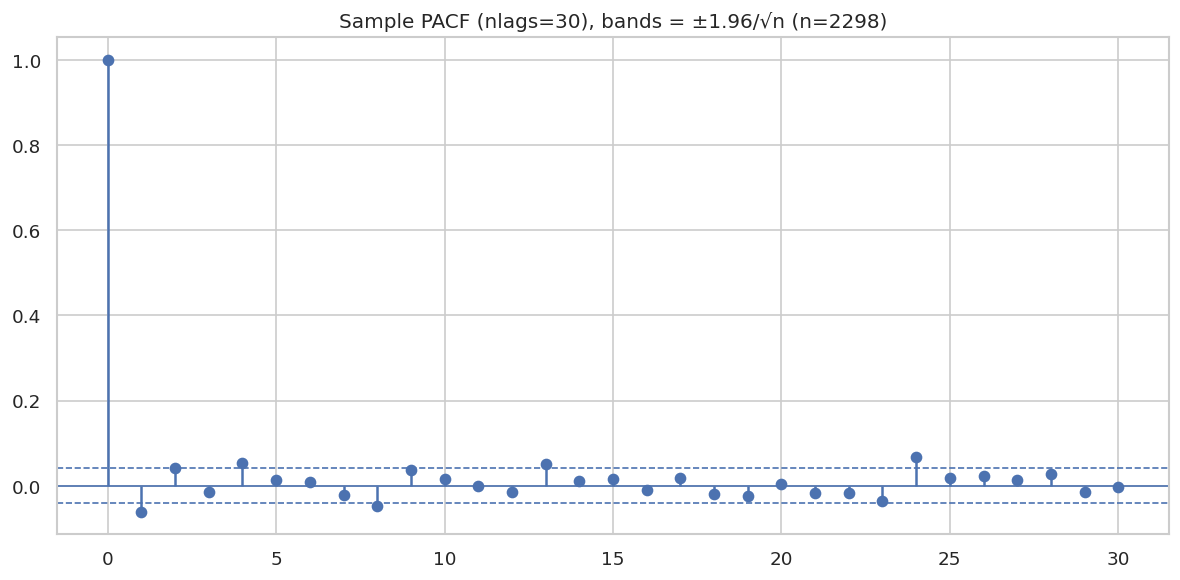

(array([ 1.    , -0.0606,  0.0447, -0.0202,  0.0567,  0.0046,  0.0129,
        -0.0232, -0.041 ,  0.0415,  0.0103,  0.0004, -0.0191,  0.0563,
         0.005 ,  0.0229, -0.0149,  0.0233, -0.0202, -0.013 ,  0.0012,
        -0.0221, -0.0125, -0.0362,  0.0714,  0.0024,  0.0328,  0.0048,
         0.0363, -0.0153,  0.0117]),
 array([ 1.    , -0.0606,  0.0412, -0.0152,  0.0531,  0.0125,  0.0092,
        -0.0211, -0.0476,  0.038 ,  0.0167, -0.0003, -0.0141,  0.0522,
         0.011 ,  0.0159, -0.0106,  0.0192, -0.0184, -0.0231,  0.0034,
        -0.0173, -0.0158, -0.0362,  0.0681,  0.0186,  0.0234,  0.0127,
         0.0287, -0.0143, -0.0022]))

In [ ]:
print("── Unit-root tests : log price ────────────────────────────────")
display(unit_root_summary(log_price, name="log(BTC-USD)"))

print("\n── Unit-root tests : log return (first difference) ───────────")
display(unit_root_summary(log_ret, name="BTC log return"))

print("\n── ACF / PACF of log return ───────────────────────────────────")
plot_acf_pacf(log_ret, nlags=30)

### ARIMA

In [ ]:
_rows, _fits = [], {}
for order in ARIMA_CANDIDATES:
    try:
        m = ARIMA(log_price, order=order, trend="n").fit()
        _fits[order] = m
        _rows.append({"order": str(order), "AIC": round(m.aic, 2),
                      "BIC": round(m.bic, 2), "loglik": round(m.llf, 2)})
    except Exception:
        pass

arima_cmp = pd.DataFrame(_rows).sort_values("AIC").reset_index(drop=True)
display(arima_cmp)

BEST_ORDER = eval(arima_cmp.loc[0, "order"])
print(f"\nSelected: ARIMA{BEST_ORDER}  (lowest AIC)")

,order,AIC,BIC,loglik
0,"(1, 1, 1)",-9266.87,-9249.65,4636.43
1,"(2, 1, 2)",-9265.68,-9236.98,4637.84
2,"(2, 1, 0)",-9264.60,-9247.38,4635.30
3,"(0, 1, 2)",-9263.86,-9246.64,4634.93
4,"(3, 1, 0)",-9263.06,-9240.10,4635.53
5,"(1, 1, 0)",-9262.49,-9251.01,4633.24
6,"(0, 1, 3)",-9262.24,-9239.28,4635.12
7,"(0, 1, 1)",-9261.83,-9250.36,4632.92
8,"(3, 1, 3)",-9260.64,-9220.46,4637.32



Selected: ARIMA(1, 1, 1)  (lowest AIC)


### Fitting

Holdout RMSE : 4,432.06 USD  |  MAPE : 5.72%


,Actual (USD),Forecast (USD),Error %
Date,,,
2026-04-13,74484.64,70886.98,4.83
2026-04-14,74181.61,70800.01,4.56
2026-04-15,74805.08,70856.61,5.28
2026-04-16,75152.13,70819.76,5.76
2026-04-17,77126.88,70843.74,8.15



Ljung-Box test on ARIMA residuals


,lb_stat,lb_pvalue
8,0.298681,0.999982
12,0.367127,1.000000
16,0.618476,1.000000
20,0.656579,1.000000


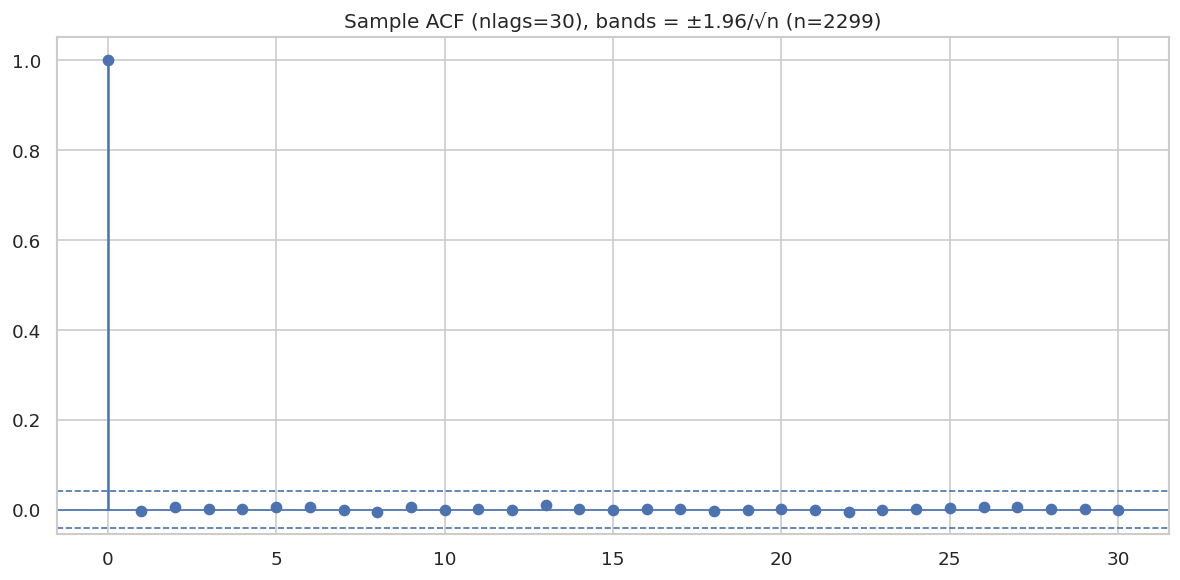

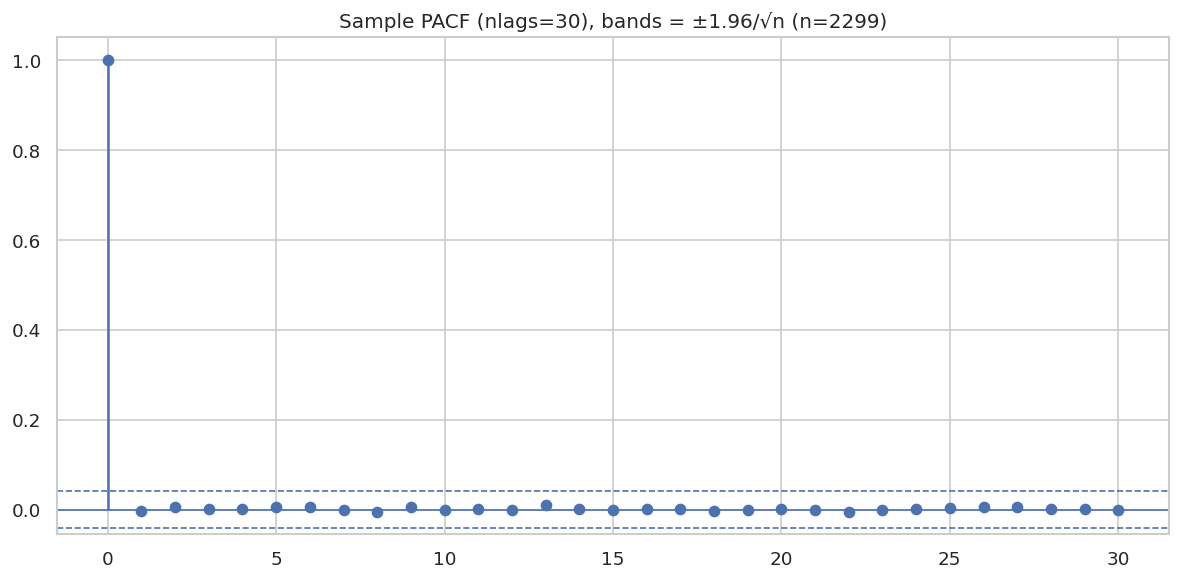

(array([ 1.    , -0.0034,  0.0053,  0.0015,  0.0009,  0.0057,  0.0057,
        -0.0017, -0.0043,  0.005 , -0.0012,  0.0016, -0.0009,  0.0101,
         0.0006, -0.0009,  0.0023,  0.0007, -0.0036, -0.0013,  0.001 ,
        -0.0015, -0.0042, -0.0007,  0.001 ,  0.003 ,  0.0049,  0.0056,
         0.0007,  0.0015, -0.0013]),
 array([ 1.    , -0.0034,  0.0053,  0.0015,  0.0009,  0.0056,  0.0058,
        -0.0017, -0.0044,  0.0049, -0.0011,  0.0015, -0.0009,  0.0102,
         0.0006, -0.0011,  0.0022,  0.0008, -0.0038, -0.0014,  0.0011,
        -0.0014, -0.0044, -0.0007,  0.0011,  0.003 ,  0.0048,  0.0057,
         0.0007,  0.0014, -0.0015]))

In [ ]:
train_lp = log_price[:-H]
test_px  = btc_close[-H:]

m_bt    = ARIMA(train_lp, order=BEST_ORDER, trend="n").fit()
fc_bt   = m_bt.forecast(steps=H)
px_fc_bt = np.exp(fc_bt.values)

from sklearn.metrics import root_mean_squared_error
bt_rmse = root_mean_squared_error(test_px.values, px_fc_bt)
bt_mape = mape(test_px.values, px_fc_bt)
print(f"Holdout RMSE : {bt_rmse:,.2f} USD  |  MAPE : {bt_mape:.2f}%")

display(pd.DataFrame({
    "Actual (USD)":   test_px.values.round(2),
    "Forecast (USD)": px_fc_bt.round(2),
    "Error %":        (np.abs(test_px.values - px_fc_bt) / test_px.values * 100).round(2),
}, index=test_px.index.strftime("%Y-%m-%d")))


arima_full  = ARIMA(log_price, order=BEST_ORDER, trend="n").fit()
arima_resid, lb = residual_report(arima_full)
print("\nLjung-Box test on ARIMA residuals")
display(lb)
plot_acf_pacf(arima_resid, nlags=30)

### ARCH

,LM stat,LM p-value,F stat,F p-value,lags
0,12.058347,0.033997,2.418072,0.033889,5


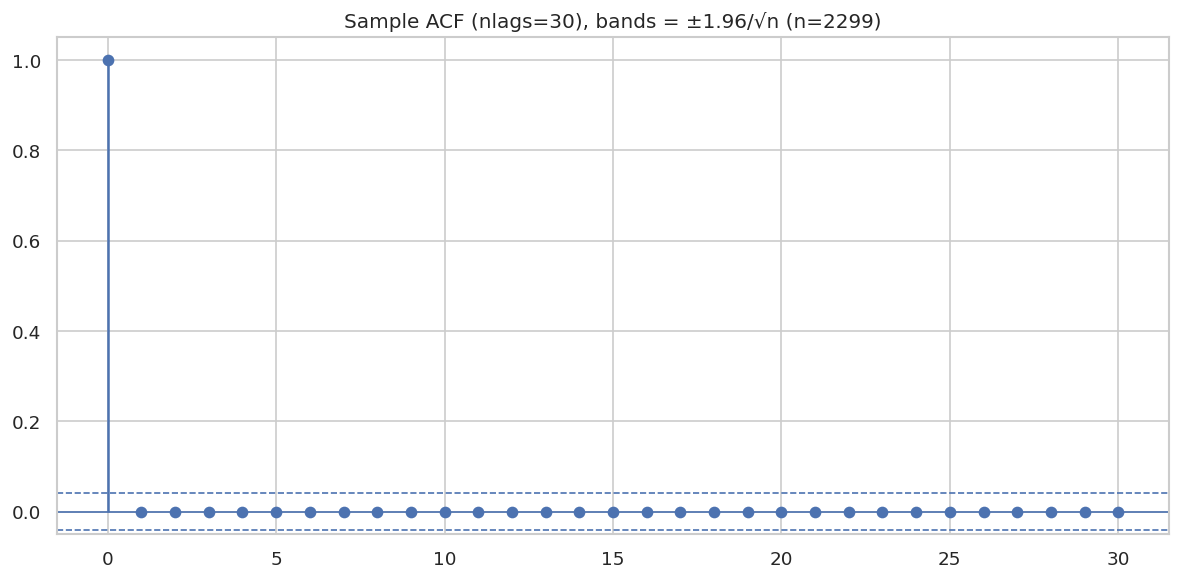

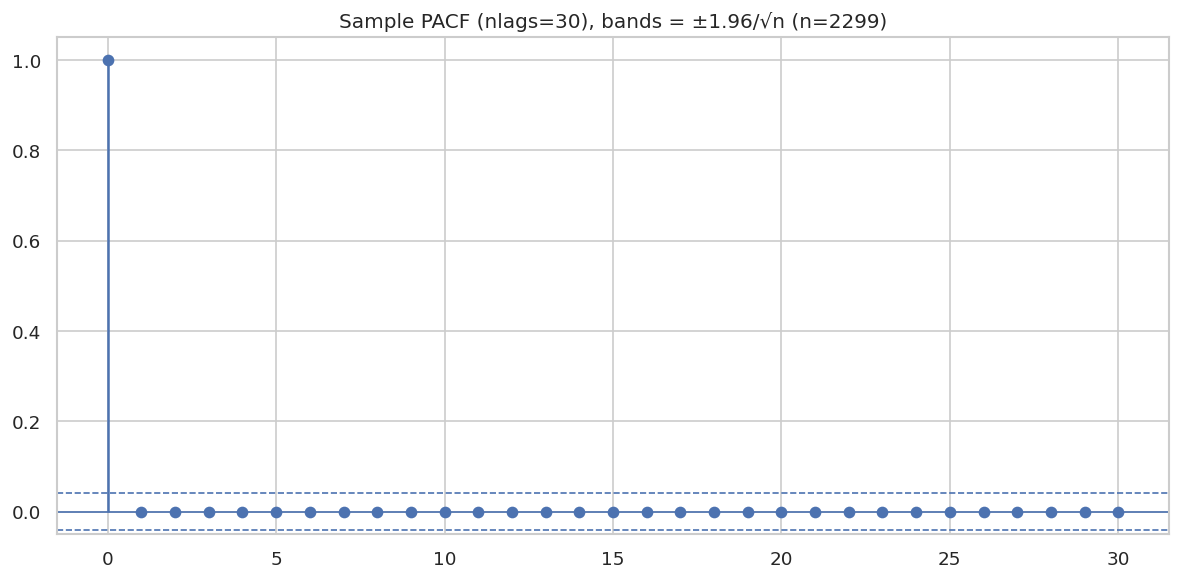

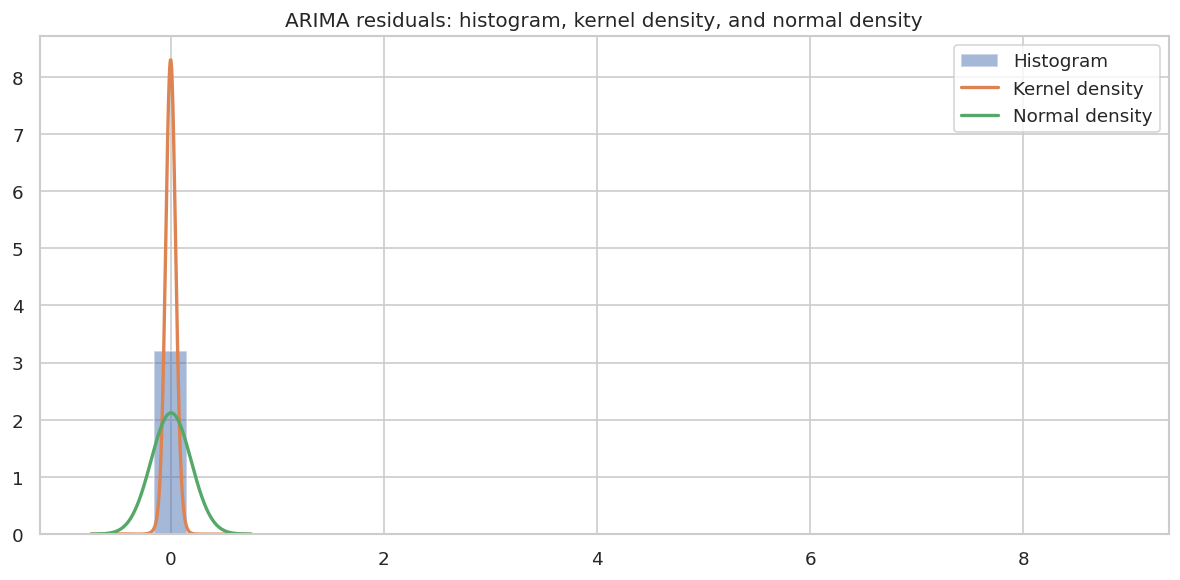

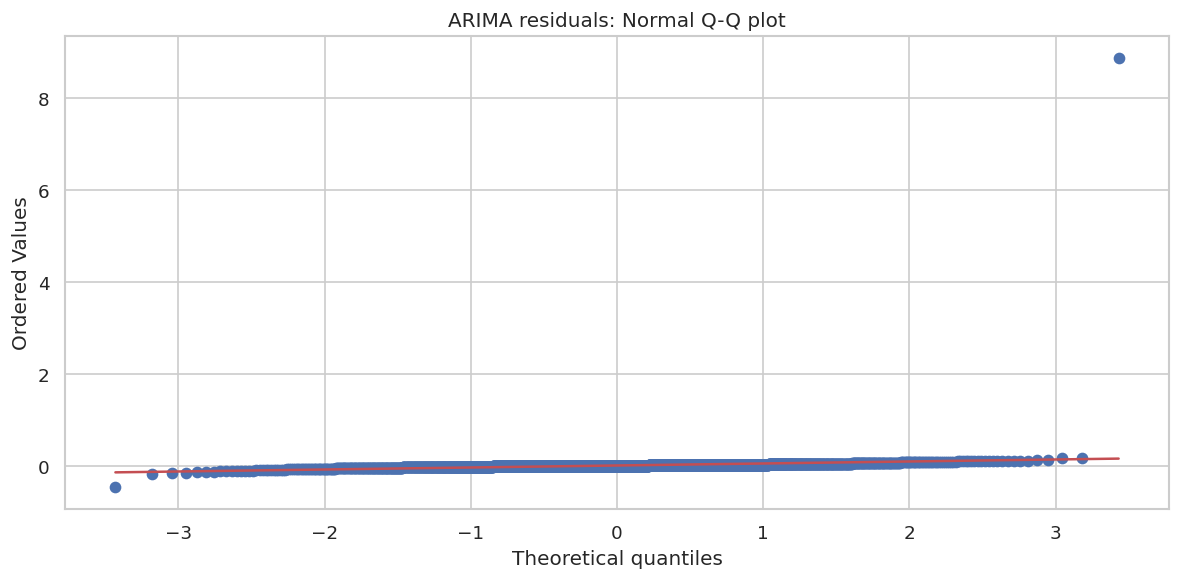

In [ ]:
resid_series = arima_full.resid.dropna()

# plot_hist_density_qq(arima_resid, title_prefix="ARIMA residuals")
display(arch_lm_table(resid_series, nlags=5))

plot_acf_pacf(resid_series**2, nlags=30)
plot_hist_density_qq(resid_series, title_prefix="ARIMA residuals")

### GARCH

                        Zero Mean - GJR-GARCH Model Results                         
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:                4484.51
Distribution:      Standardized Student's t   AIC:                          -8959.02
Method:                  Maximum Likelihood   BIC:                          -8930.31
                                              No. Observations:                 2299
Date:                      Sun, Apr 19 2026   Df Residuals:                     2299
Time:                              02:55:13   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omeg

,LM stat,LM p-value,F stat,F p-value,lags
0,5.353284,0.374302,1.070354,0.374785,5


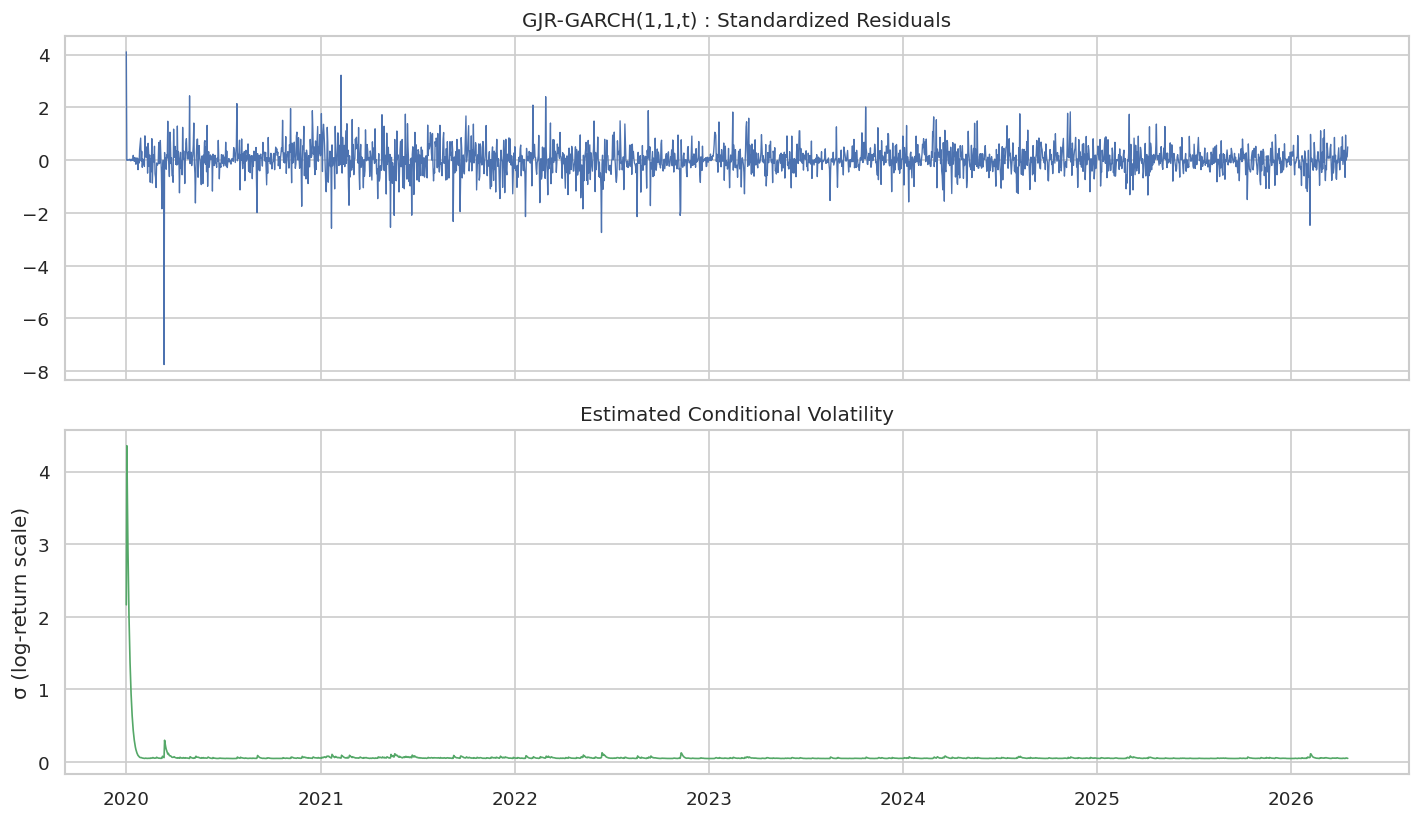

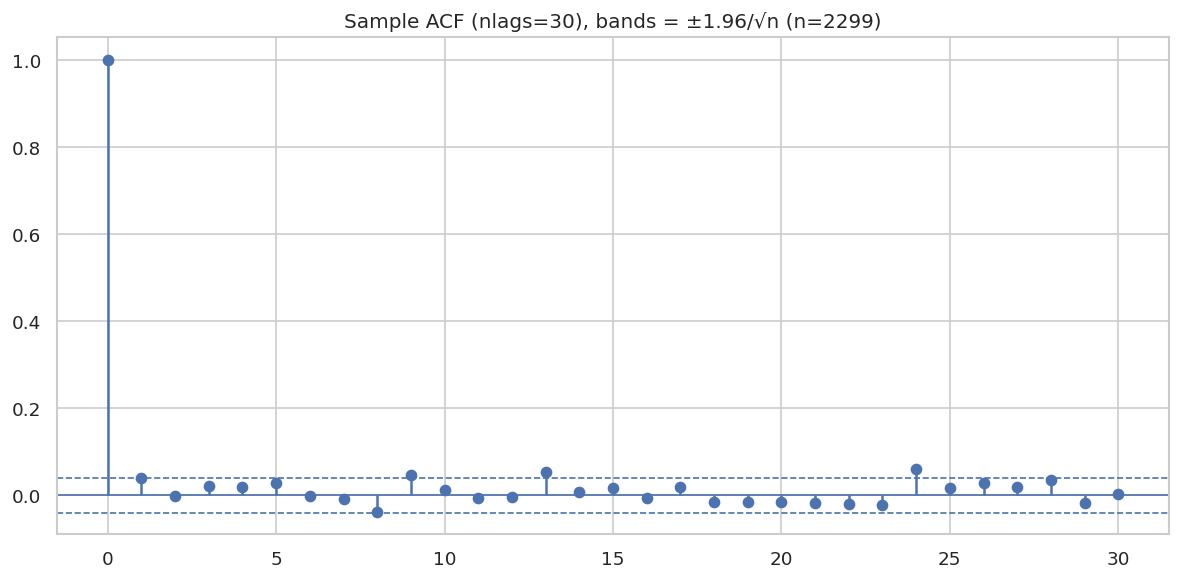

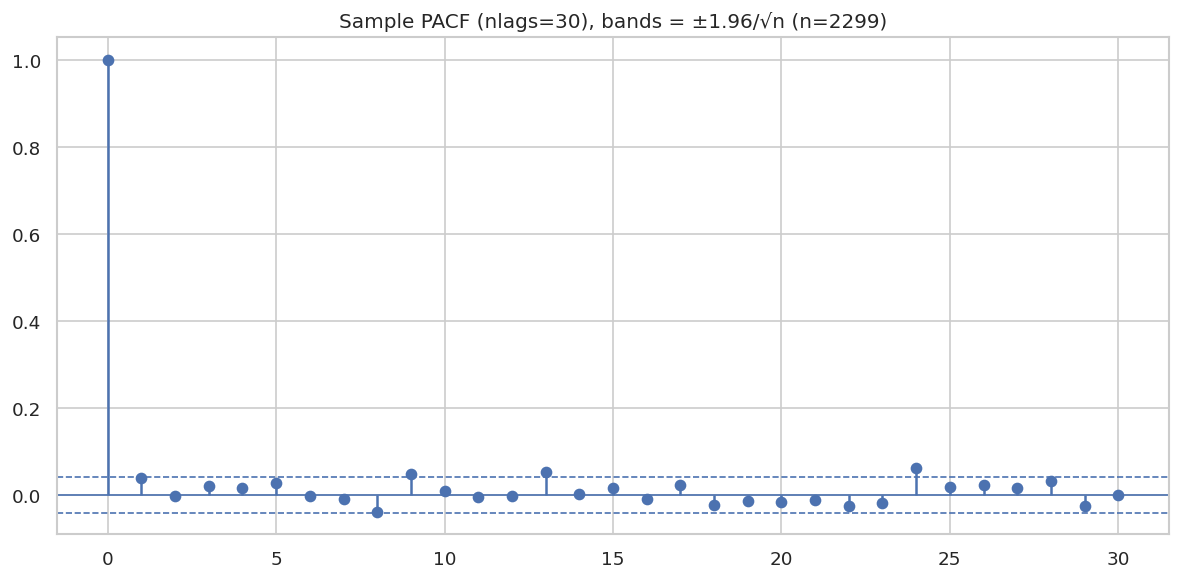

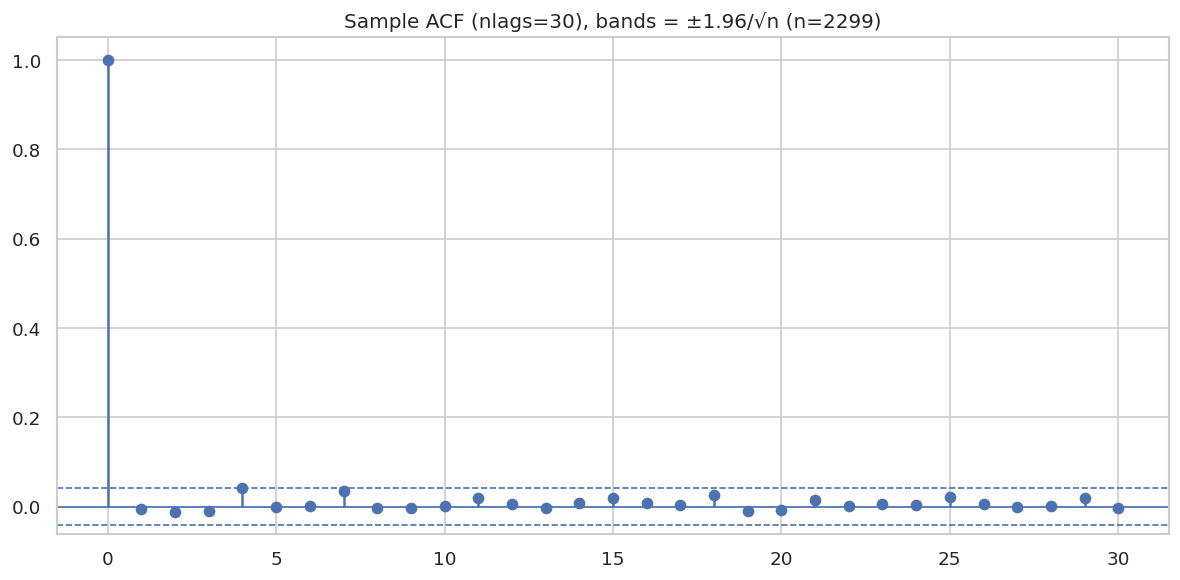

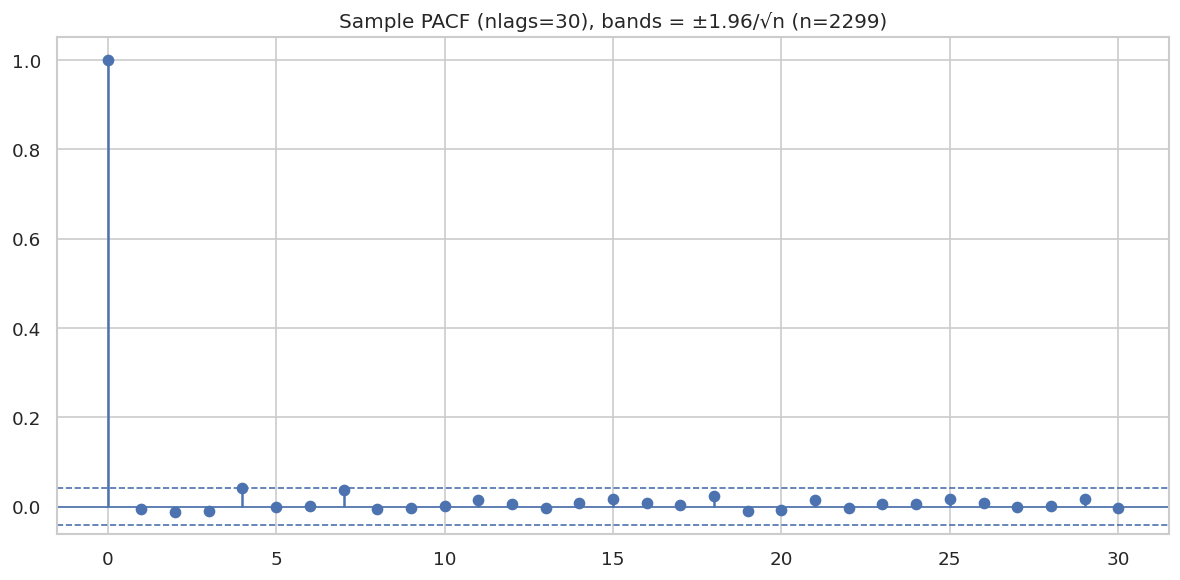

(array([ 1.    , -0.0051, -0.0111, -0.0097,  0.0425, -0.0003,  0.0004,
         0.0356, -0.0028, -0.0027,  0.0011,  0.0188,  0.006 , -0.0033,
         0.008 ,  0.0183,  0.0075,  0.004 ,  0.0258, -0.0087, -0.007 ,
         0.0158,  0.0005,  0.0053,  0.0041,  0.0205,  0.0067, -0.0007,
         0.0019,  0.0183, -0.0028]),
 array([ 1.    , -0.0051, -0.0111, -0.0099,  0.0423, -0.0001,  0.0013,
         0.0365, -0.0043, -0.002 ,  0.0017,  0.0156,  0.0065, -0.0027,
         0.0071,  0.0173,  0.0074,  0.0047,  0.0246, -0.0101, -0.0068,
         0.0152, -0.0034,  0.0057,  0.0049,  0.0174,  0.0075, -0.0006,
         0.0007,  0.0161, -0.004 ]))

In [ ]:
from arch import arch_model

garch_final = arch_model(
    resid_series, mean="Zero", vol="GARCH", p=1, o=1, q=1, dist="t"
).fit(disp="off", show_warning=False)

print(garch_final.summary())

std_resid = garch_final.std_resid
cond_vol  = garch_final.conditional_volatility

print("\n── ARCH-LM on standardized residuals ──────────────────────────")
display(arch_lm_table(std_resid, nlags=5))

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(std_resid.index, std_resid.values, linewidth=0.8)
axes[0].set_title("GJR-GARCH(1,1,t) : Standardized Residuals")
axes[1].plot(cond_vol.index, cond_vol.values, linewidth=1, color="C2")
axes[1].set_title("Estimated Conditional Volatility")
axes[1].set_ylabel("σ (log-return scale)")
plt.tight_layout()
plt.show()

plot_acf_pacf(std_resid,    nlags=30)
plot_acf_pacf(std_resid**2, nlags=30)

### Prediction

ARIMA(1, 1, 1) + GJR-GARCH(1,1,t) — BTC-USD Forecast
Data up to : 2026-04-17



,Forecast (USD),Lower 95% (USD),Upper 95% (USD),Cond. σ (log)
Date,,,,
2026-04-20,76973.18,69756.02,84937.03,0.05023
2026-04-21,77072.41,66468.72,89367.69,0.07552
2026-04-22,77008.30,63600.13,93243.18,0.09760
2026-04-23,77049.70,61112.12,97143.68,0.11823
2026-04-24,77022.96,58766.62,100950.79,0.13803


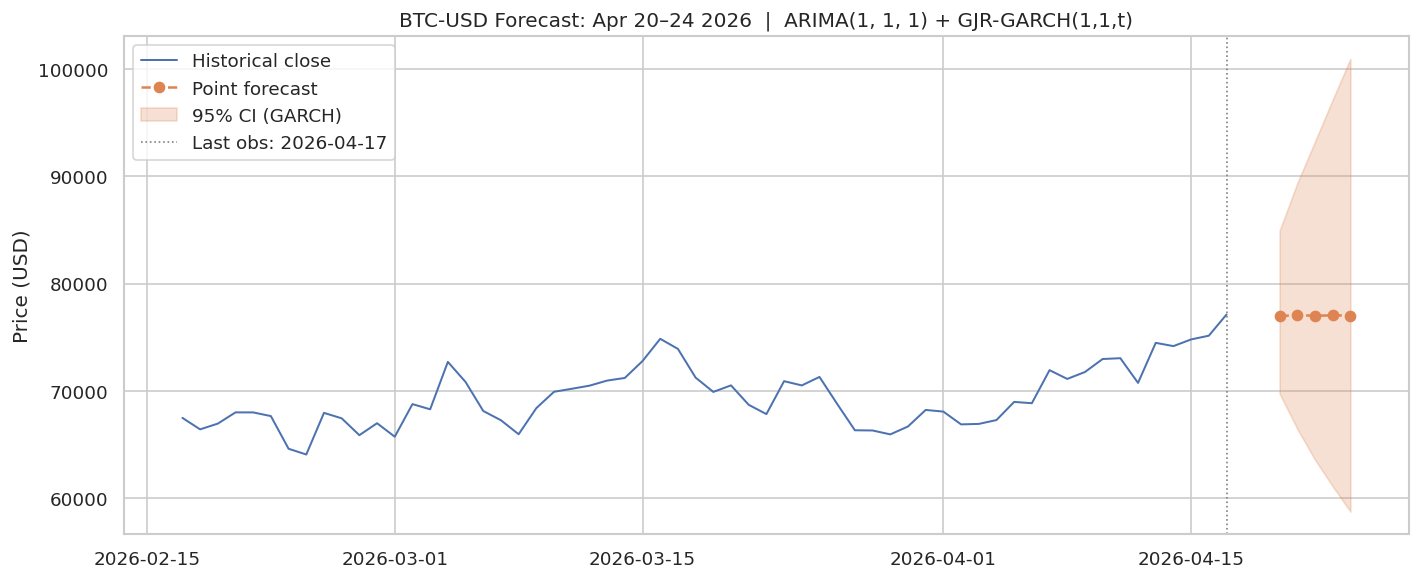

In [ ]:
log_fc       = arima_full.get_forecast(steps=H).predicted_mean
log_fc.index = FORECAST_DATES

garch_fc  = garch_final.forecast(horizon=H, reindex=False)
garch_var = garch_fc.variance.values[-1]      # shape (H,)
cum_sigma = np.sqrt(np.cumsum(garch_var))


price_fc = np.exp(log_fc.values)
price_lo = np.exp(log_fc.values - 1.96 * cum_sigma)
price_hi = np.exp(log_fc.values + 1.96 * cum_sigma)


fc_tbl = pd.DataFrame({
    "Forecast (USD)":    price_fc.round(2),
    "Lower 95% (USD)":   price_lo.round(2),
    "Upper 95% (USD)":   price_hi.round(2),
    "Cond. σ (log)":     cum_sigma.round(5),
}, index=FORECAST_DATES.strftime("%Y-%m-%d"))
fc_tbl.index.name = "Date"

print(f"ARIMA{BEST_ORDER} + GJR-GARCH(1,1,t) — BTC-USD Forecast")
print(f"Data up to : {btc_close.index[-1].date()}\n")
display(fc_tbl)


fig, ax = plt.subplots(figsize=(12, 5))

history_tail = btc_close[-60:]
ax.plot(history_tail.index, history_tail.values,
        linewidth=1.2, label="Historical close", color="C0")
ax.plot(FORECAST_DATES, price_fc,
        "o--", linewidth=1.5, markersize=6, color="C1", label="Point forecast")
ax.fill_between(FORECAST_DATES, price_lo, price_hi,
                alpha=0.25, color="C1", label="95% CI (GARCH)")
ax.axvline(btc_close.index[-1], linestyle=":", linewidth=1, color="grey",
           label=f"Last obs: {btc_close.index[-1].date()}")

ax.set_title(f"BTC-USD Forecast: Apr 20–24 2026  |  ARIMA{BEST_ORDER} + GJR-GARCH(1,1,t)")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()

### XGBoost

In [ ]:
import xgboost as xgb

VAL_DAYS = 30   # shared by XGBoost and LSTM

# ── Feature engineering ──────────────────────────────────────────────
def make_btc_features(series, lags=[1,2,3,5,7,14,21,28]):
    df = series.to_frame(name="lp")
    for lag in lags:
        df[f"lag_{lag}"] = df["lp"].shift(lag)
    for w in [7, 14, 30]:
        df[f"roll_mean_{w}"] = df["lp"].shift(1).rolling(w).mean()
        df[f"roll_std_{w}"]  = df["lp"].shift(1).rolling(w).std()
    df["diff_1"] = df["lp"].diff(1)
    df["diff_7"] = df["lp"].diff(7)
    return df

feat_cols = [c for c in make_btc_features(log_price).columns if c != "lp"]

df_xgb = make_btc_features(log_price).copy()
for step in range(1, H + 1):
    df_xgb[f"y_{step}"] = log_price.shift(-step)
df_xgb = df_xgb.dropna()

n = len(df_xgb)
train_xgb      = df_xgb.iloc[: n - 1 - VAL_DAYS]
val_xgb        = df_xgb.iloc[n - 1 - VAL_DAYS : n - 1]
holdout_origin = df_xgb.iloc[-1]
print(f"Train: {len(train_xgb)}, Val: {len(val_xgb)}, Holdout: 1 origin → {H} steps")

xgb_models = {}
for step in range(1, H + 1):
    mdl = xgb.XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        early_stopping_rounds=30, random_state=42,
    )
    mdl.fit(train_xgb[feat_cols], train_xgb[f"y_{step}"],
            eval_set=[(val_xgb[feat_cols], val_xgb[f"y_{step}"])],
            verbose=False)
    xgb_models[step] = mdl
    print(f"  Step {step}: best_iteration = {mdl.best_iteration + 1}")

# Holdout evaluation
origin_feat = holdout_origin[feat_cols].values.reshape(1, -1)
xgb_fc_bt   = np.array([xgb_models[s].predict(origin_feat)[0] for s in range(1, H + 1)])
xgb_px_bt   = np.exp(xgb_fc_bt)

xgb_rmse_val = root_mean_squared_error(test_px.values, xgb_px_bt)
xgb_mape_val = mape(test_px.values, xgb_px_bt)
print(f"\nHoldout RMSE: {xgb_rmse_val:,.2f} USD  |  MAPE: {xgb_mape_val:.2f}%")
display(pd.DataFrame({
    "Actual (USD)": test_px.values.round(2),
    "XGB Forecast": xgb_px_bt.round(2),
    "Error %":      (np.abs(test_px.values - xgb_px_bt) / test_px.values * 100).round(2),
}, index=test_px.index.strftime("%Y-%m-%d")))

# Final forecast: April 20-24
last_feat    = make_btc_features(log_price).dropna(subset=feat_cols).iloc[-1][feat_cols].values.reshape(1, -1)
xgb_fc_final = np.array([xgb_models[s].predict(last_feat)[0] for s in range(1, H + 1)])
xgb_px_final = np.exp(xgb_fc_final)
print(f"\nXGBoost Final Forecast:")
for d, p in zip(FORECAST_DATES, xgb_px_final):
    print(f"  {d.date()}: ${p:,.2f}")

Train: 2233, Val: 30, Holdout: 1 origin → 5 steps
  Step 1: best_iteration = 143
  Step 2: best_iteration = 155
  Step 3: best_iteration = 137
  Step 4: best_iteration = 138
  Step 5: best_iteration = 78

Holdout RMSE: 5,465.48 USD  |  MAPE: 7.17%


,Actual (USD),XGB Forecast,Error %
Date,,,
2026-04-13,74484.64,69561.671875,6.61
2026-04-14,74181.61,69345.281250,6.52
2026-04-15,74805.08,70347.101562,5.96
2026-04-16,75152.13,69229.710938,7.88
2026-04-17,77126.88,70287.070312,8.87



XGBoost Final Forecast:
  2026-04-20: $73,341.63
  2026-04-21: $72,563.41
  2026-04-22: $72,654.25
  2026-04-23: $72,583.27
  2026-04-24: $72,205.68


### LSTM

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42);  np.random.seed(42)
print(f"Device: {device}")

SEQ_LEN = 30


lp_scaler = StandardScaler()
lp_scaled  = lp_scaler.fit_transform(log_price.values.reshape(-1, 1)).flatten()



all_X = np.array([lp_scaled[i : i+SEQ_LEN]           for i in range(len(lp_scaled)-SEQ_LEN-H+1)])
all_y = np.array([lp_scaled[i+SEQ_LEN : i+SEQ_LEN+H] for i in range(len(lp_scaled)-SEQ_LEN-H+1)])

N = len(all_X)
train_X, train_y = all_X[: N-1-VAL_DAYS], all_y[: N-1-VAL_DAYS]
val_X,   val_y   = all_X[N-1-VAL_DAYS : N-1], all_y[N-1-VAL_DAYS : N-1]
print(f"Train: {len(train_X)}, Val: {len(val_X)}, Holdout: 1 sample × {H} steps")

train_loader = DataLoader(
    TensorDataset(
        torch.FloatTensor(train_X).unsqueeze(-1),  # (N, SEQ_LEN, 1)
        torch.FloatTensor(train_y)                  # (N, H)
    ), batch_size=32, shuffle=True
)
val_X_t = torch.FloatTensor(val_X).unsqueeze(-1).to(device)
val_y_t = torch.FloatTensor(val_y).to(device)


class LSTMForecast(nn.Module):
    def __init__(self, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, layers, batch_first=True,
                            dropout=dropout if layers > 1 else 0.)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, H)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

model     = LSTMForecast().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
criterion = nn.MSELoss()


EPOCHS, PATIENCE = 200, 20
best_val, best_state, patience_ctr = float("inf"), None, 0

for epoch in range(EPOCHS):
    model.train()
    ep_loss = 0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        loss = criterion(model(bx), by)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ep_loss += loss.item() * len(bx)

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(val_X_t), val_y_t).item()
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val      = val_loss
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr  = 0
    else:
        patience_ctr += 1

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}  train={ep_loss/len(train_X):.6f}  val={val_loss:.6f}")
    if patience_ctr >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

model.load_state_dict(best_state)
print(f"Best val loss: {best_val:.6f}")

# Holdout evaluation
model.eval()
with torch.no_grad():
    holdout_in        = torch.FloatTensor(all_X[-1]).unsqueeze(0).unsqueeze(-1).to(device)
    lstm_fc_bt_scaled = model(holdout_in).cpu().numpy().flatten()

lstm_fc_bt_log = lp_scaler.inverse_transform(lstm_fc_bt_scaled.reshape(-1, 1)).flatten()
lstm_px_bt     = np.exp(lstm_fc_bt_log)

lstm_rmse_val = root_mean_squared_error(test_px.values, lstm_px_bt)
lstm_mape_val = mape(test_px.values, lstm_px_bt)
print(f"\nHoldout RMSE: {lstm_rmse_val:,.2f} USD  |  MAPE: {lstm_mape_val:.2f}%")
display(pd.DataFrame({
    "Actual (USD)":  test_px.values.round(2),
    "LSTM Forecast": lstm_px_bt.round(2),
    "Error %":       (np.abs(test_px.values - lstm_px_bt) / test_px.values * 100).round(2),
}, index=test_px.index.strftime("%Y-%m-%d")))

# Final forecast: April 20-24
with torch.no_grad():
    final_in          = torch.FloatTensor(lp_scaled[-SEQ_LEN:]).unsqueeze(0).unsqueeze(-1).to(device)
    lstm_fc_fin_scaled = model(final_in).cpu().numpy().flatten()

lstm_fc_final_log = lp_scaler.inverse_transform(lstm_fc_fin_scaled.reshape(-1, 1)).flatten()
lstm_px_final     = np.exp(lstm_fc_final_log)
print(f"\nLSTM Final Forecast:")
for d, p in zip(FORECAST_DATES, lstm_px_final):
    print(f"  {d.date()}: ${p:,.2f}")

Device: cpu
Train: 2234, Val: 30, Holdout: 1 sample × 5 steps
Epoch  20  train=0.028789  val=0.007316
Epoch  40  train=0.028224  val=0.003086
Early stopping at epoch 45
Best val loss: 0.002412

Holdout RMSE: 3,236.88 USD  |  MAPE: 4.07%


,Actual (USD),LSTM Forecast,Error %
Date,,,
2026-04-13,74484.64,72030.921875,3.29
2026-04-14,74181.61,72028.718750,2.90
2026-04-15,74805.08,72128.460938,3.58
2026-04-16,75152.13,72088.429688,4.08
2026-04-17,77126.88,72108.851562,6.51



LSTM Final Forecast:
  2026-04-20: $74,982.63
  2026-04-21: $75,010.17
  2026-04-22: $75,090.48
  2026-04-23: $75,032.20
  2026-04-24: $75,054.11


### Comparison

=== Holdout Performance (last 5 days) ===


,Model,RMSE (USD),MAPE (%)
0,LSTM,3236.88,4.07
1,ARIMA+GARCH,4432.06,5.72
2,XGBoost,5465.48,7.17



=== Final Forecast: Apr 20–24 2026 ===


,ARIMA+GARCH (USD),XGBoost (USD),LSTM (USD)
Date,,,
2026-04-20,76973.18,73341.640625,74982.640625
2026-04-21,77072.41,72563.398438,75010.171875
2026-04-22,77008.30,72654.250000,75090.476562
2026-04-23,77049.70,72583.257812,75032.203125
2026-04-24,77022.96,72205.679688,75054.109375


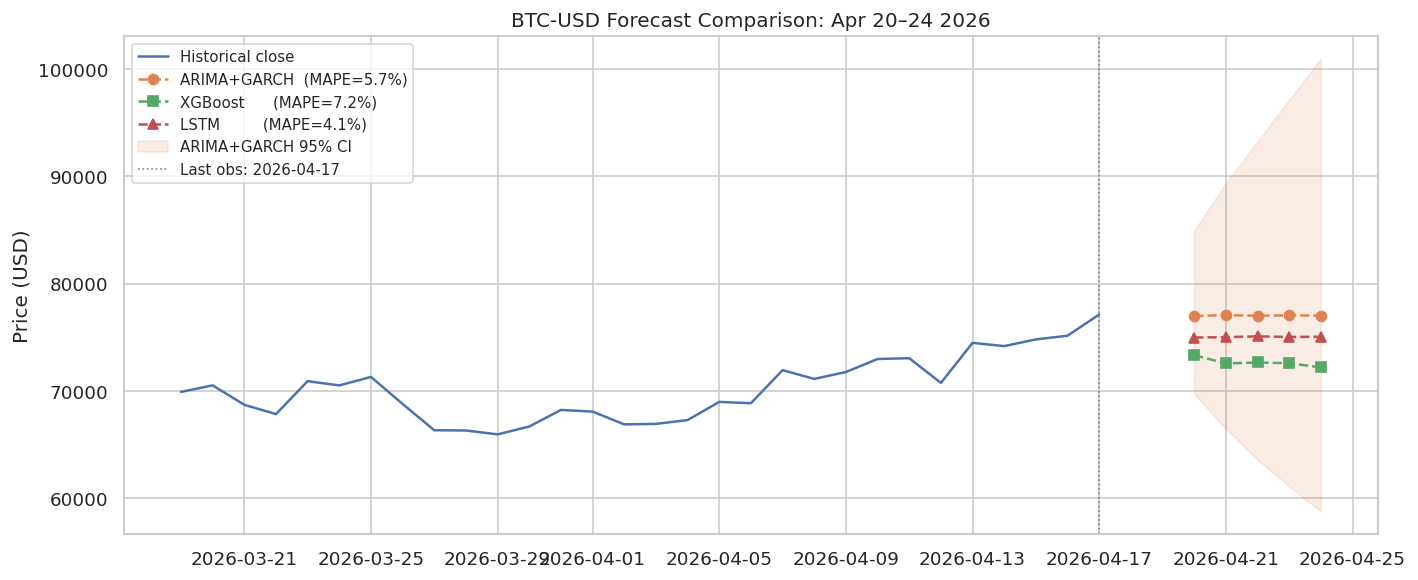

In [ ]:
comparison = pd.DataFrame({
    "Model":      ["ARIMA+GARCH", "XGBoost", "LSTM"],
    "RMSE (USD)": [round(bt_rmse, 2),      round(xgb_rmse_val, 2), round(lstm_rmse_val, 2)],
    "MAPE (%)":   [round(bt_mape, 2),      round(xgb_mape_val, 2), round(lstm_mape_val, 2)],
}).sort_values("MAPE (%)").reset_index(drop=True)
print("=== Holdout Performance (last 5 days) ===")
display(comparison)

# Final forecast table
forecast_summary = pd.DataFrame({
    "Date":              FORECAST_DATES.strftime("%Y-%m-%d"),
    "ARIMA+GARCH (USD)": price_fc.round(2),
    "XGBoost (USD)":     xgb_px_final.round(2),
    "LSTM (USD)":        lstm_px_final.round(2),
}).set_index("Date")
print("\n=== Final Forecast: Apr 20–24 2026 ===")
display(forecast_summary)

# Comparison plot
fig, ax = plt.subplots(figsize=(12, 5))

tail = btc_close[-30:]
ax.plot(tail.index, tail.values, linewidth=1.5, color="C0", label="Historical close")
ax.plot(FORECAST_DATES, price_fc,       "o--", linewidth=1.5, color="C1", label=f"ARIMA+GARCH  (MAPE={bt_mape:.1f}%)")
ax.plot(FORECAST_DATES, xgb_px_final,   "s--", linewidth=1.5, color="C2", label=f"XGBoost      (MAPE={xgb_mape_val:.1f}%)")
ax.plot(FORECAST_DATES, lstm_px_final,  "^--", linewidth=1.5, color="C3", label=f"LSTM         (MAPE={lstm_mape_val:.1f}%)")
ax.fill_between(FORECAST_DATES, price_lo, price_hi, alpha=0.15, color="C1", label="ARIMA+GARCH 95% CI")

ax.axvline(btc_close.index[-1], linestyle=":", linewidth=1, color="grey",
           label=f"Last obs: {btc_close.index[-1].date()}")
ax.set_title("BTC-USD Forecast Comparison: Apr 20–24 2026")
ax.set_ylabel("Price (USD)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()